# E3SM-FOSIRL, E3SM-Reanalysis, E3SM-4DEnVarOcn, and CESM-SMYLE Seasonal Modes-of-Variability Analysis

Analyze the official PMP extra-tropical modes (`NAM`, `NAO`, `SAM`, `PNA`,
`NPO`, `PDO`, and `NPGO`) and the ESP-Lab extensions (`EA`, `SCA`, and
`AMO`). Set `selected_mode` in the control panel. NAO includes station-
and EOF-based skill; all other modes use the common-basis EOF index.

This revised notebook ensures the processed products for the selected mode,
then performs the scientific analysis. It calls the reusable modes processor
directly, so the optional `preprocessing/mov/0_run_sigmod_emov.ipynb` and
`preprocessing/mov/0_run_nmme_emov.ipynb` batch drivers do not need to be
run first.


In [294]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import json
import os
import sys
import warnings
import re
import uuid
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Make repository-local modules importable even when Jupyter starts in jupyter/.
_repo_override = os.environ.get("ESP_LAB_REPO_ROOT")
_repo_candidates = (
    [Path(_repo_override).expanduser().resolve()]
    if _repo_override
    else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
)
REPO_ROOT = next(
    (candidate for candidate in _repo_candidates
     if (candidate / "workflows" / "modes_of_variability" / "orchestration.py").is_file()
     and (candidate / "esp_lab").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Cannot locate the ESP-Lab checkout. Start Jupyter inside ESP-Lab "
        "or set ESP_LAB_REPO_ROOT to the checkout directory."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
    
from esp_lab import stats
from esp_lab.utils import mov_utils as mov

# ---------------------------------------------------------------------
# Figure configuration
# ---------------------------------------------------------------------
# Shared defaults and reusable layout/map presets live in figure_config.
# MODE_FIGURE_PROFILES is the single place containing mode-specific choices.
from workflows.modes_of_variability.figure_config import (
    ALBERS_PROJECTION_BY_MODE,
    MODE_FIGURE_PROFILES,
    build_figure_setup,
    metric_specs as get_metric_specs,
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [295]:
print("xarray:", xr.__version__)
print("map utilities:", getattr(mov, "__file__", "module object"))
print("cartopy available:", mov.has_cartopy())

xarray: 2026.4.0
map utilities: /global/u2/z/zhan391/code/ESP-Lab/esp_lab/utils/mov_utils.py
cartopy available: True


## User Control Panel


In [296]:
%%time
official_pmp_modes = ("NAM", "NAO", "SAM", "PNA", "NPO", "PDO", "NPGO")
extension_modes = ("EA", "SCA", "AMO", "PSA1", "PSA2")
supported_modes = official_pmp_modes + extension_modes
temperature_modes = {"PDO", "NPGO", "AMO"}

#selected_mode = "PSA1" #"PNA" #"NAM" #"SAM" #"PSA2" #"PSA1"
selected_mode = "EA" #"NPO" #"NAO" # "EA" # "SCA" 
#selected_mode = "PDO" #"AMO" #"PDO" #"NPGO"
selected_mode = selected_mode.upper().strip()

# Upstream processing policy: auto reuses compatible products and builds
# missing/stale products; require performs validation only; rebuild forces
# regeneration for the selected mode.
mov_input_mode = "auto" #"require"

# Optional common processing end year. None uses the end year from MOV_INPUT_SETTINGS.
YEAR_END = 2011  # None

climy0 = 1981
climy1 = 2010
init_months = [5, 11]
seasonal_nlead = 7
skill_lead_axis = "seasonal_target_months"
skill_detrend = True
force_recompute_skill = False
write_summary_tables = True

analysis_methods = ["eof"]
if selected_mode == "NAO":
    analysis_methods = ["station", "eof"]

# Upstream processing policy: auto reuses compatible products and builds
# missing/stale products; require performs validation only; rebuild forces
# regeneration for the selected mode.
mode_observation_years = (1950, 2020) if selected_mode in temperature_modes else (1979, 2019)
mode_eof_reference_years = mode_observation_years
MOV_E3SM_CASES = {
    "E3SM-FOSIRL": {
        "data_dir": "/global/cfs/cdirs/e3sm/S2S2D/post_process",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "cache_tag": "JRA55_FOSIRL",
        "display_name": "E3SMv3-FOSIRL",
    },
    "E3SM-Reanalysis": {
        "data_dir": "/global/cfs/cdirs/e3sm/S2S2D/post_process",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "cache_tag": "Reanalysis",
        "display_name": "E3SMv3-Reanalysis",
    },
    "E3SM-4DEnVarOcn": {
        "data_dir": "/global/cfs/cdirs/e3sm/S2S2D/post_process",
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "cache_tag": "4DEnVarOcn",
        "display_name": "E3SMv3-4DEnVarOcn",
    },
}

# -----------------------------------------------------------------------------
# Directory setup
# -----------------------------------------------------------------------------
S2D_DIAG_ROOT = Path("/global/cfs/cdirs/e3sm/S2S2D/s2d_diag")
E3SMLE_DIAG_DIR = S2D_DIAG_ROOT
CESM_SMYLE_DIAG_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
NMME_DIAG_DIR = S2D_DIAG_ROOT / "NMME"
MODES_VARIABILITY_DIAG_DIR = S2D_DIAG_ROOT

# Override the root for a different workspace with ESP_LAB_S2D_DIAG_ROOT.
DIAG_ROOT = S2D_DIAG_ROOT
E3SMLE_OUTDIR = E3SMLE_DIAG_DIR
CESM_SMYLE_OUTDIR = CESM_SMYLE_DIAG_DIR
SMYLE_BENCHMARK_DIR = str(CESM_SMYLE_OUTDIR)
NMME_OUTDIR = NMME_DIAG_DIR
MODES_OUTDIR = MODES_VARIABILITY_DIAG_DIR

if selected_mode not in supported_modes:
    raise ValueError(
        f"selected_mode must be one of {supported_modes}, got {selected_mode!r}"
    )

FIGURE_OUTDIR = Path(
    os.environ.get("ESP_LAB_FIGURE_ROOT", "/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
)
try:
    FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)
except (PermissionError, OSError):
    FIGURE_OUTDIR = analysis_outdir / "figures" / selected_mode.lower()
    FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

analysis_outdir = MODES_OUTDIR
manifest_file = analysis_outdir / "_manifests" / "modes_manifest.json"
legacy_manifest_file = analysis_outdir / "modes_manifest.json"
if not manifest_file.exists() and legacy_manifest_file.exists():
    manifest_file = legacy_manifest_file
index_cache_dir = analysis_outdir / "modes" / selected_mode.lower() / "indices"
# Tables below combine several forecast sources, so keep them outside any
# individual source directory and give them an explicit multi-model owner.
multimodel_analysis_outdir = analysis_outdir / "multimodel" / "modes_variability"
table_outdir = multimodel_analysis_outdir / "tables"

# Analysis labels map to cache tags written by the reusable modes processor.
# NMME is optional because not every mode/init combination is always processed.
include_nmme = False
core_model_product_tags = {
    "E3SM-FOSIRL": "JRA55_FOSIRL",
    "E3SM-Reanalysis": "Reanalysis",
    "E3SM-4DEnVarOcn": "4DEnVarOcn",
    "SMYLE": "smyle",
}
optional_model_product_tags = {"NMME": "nmme"}
model_product_tags = dict(core_model_product_tags)
model_source_dirs = {
    "E3SM-FOSIRL": "JRA55_FOSIRL",
    "E3SM-Reanalysis": "Reanalysis",
    "E3SM-4DEnVarOcn": "4DEnVarOcn",
    "SMYLE": "CESM-SMYLE",
    "NMME": "NMME",
}
model_expected_sources = {
    "E3SM-FOSIRL": "E3SM",
    "E3SM-Reanalysis": "E3SM",
    "E3SM-4DEnVarOcn": "E3SM",
    "SMYLE": "SMYLE",
    "NMME": "NMME",
}
model_display_names = {
    "E3SM-FOSIRL": "E3SMv3-FOSIRL",
    "E3SM-Reanalysis": "E3SMv3-Reanalysis",
    "E3SM-4DEnVarOcn": "E3SMv3-4DEnVarOcn",
    "SMYLE": "CESM-SMYLE",
    "NMME": "NMME",
}
models = tuple(model_product_tags)

MOV_INPUT_SETTINGS = {
    "ensure_mode": mov_input_mode,
    "mode": selected_mode,
    "outdir": analysis_outdir,
    "year_end": YEAR_END,
    "years": (1980, 2018 if YEAR_END is None else int(YEAR_END)),
    "climatology_years": (1981, 2010),
    "observation_years": mode_observation_years,
    "eof_reference_years": mode_eof_reference_years,
    "init_months": init_months,
    "monthly_nlead": 24,
    "target_dlat": 2.5,
    "target_dlon": 2.5,
    "regrid_method": "conservative",
    "workers": 4,
    "eof_bootstrap_iterations": 200,
    "ensure_global_teleconnections": True,
    "regression_alpha": 0.05,
    "regression_fdr": True,
    "regression_standardize_index": True,
    "model_sst_land_mask": True,
    "obs_dir": "/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series",
    "psl_obs_product": "ERA5",
    "psl_obs_var": "psl",
    "ts_obs_product": "HadISST2",
    "ts_obs_var": "sst",
    "smyle_data_dir": "/global/cfs/cdirs/e3sm/S2S2D/CESM-SMYLE",
    "smyle_benchmark_dir": CESM_SMYLE_OUTDIR,
    "smyle_nens": 20,
    "e3sm_cases": MOV_E3SM_CASES,
    "include_nmme": include_nmme,
    "nmme_root": "/global/cfs/cdirs/e3sm/S2S2D/NMME/data_hindcast_by_member",
    "nmme_fixed_dir": NMME_OUTDIR / "fixed",
    "nmme_models": [],  # Empty discovers models with the required field.
    "nmme_field": "auto",
    "nmme_chunks": "",
    "nmme_sst_land_mask": True,
}

FIGURE_SETUP = build_figure_setup(selected_mode, include_nmme=include_nmme)

fontz = FIGURE_SETUP["common"]["fontsize"]
figure_dpi = FIGURE_SETUP["common"]["dpi"]
eof_settings = FIGURE_SETUP["eof_patterns"]

# Derived sizes used by plotting cells.
suptitle_fontsize = fontz * eof_settings.get("suptitle_scale", 1.00)
column_header_fontsize = fontz * eof_settings.get("column_header_scale", 0.95)
panel_title_fontsize = fontz * eof_settings.get("panel_title_scale", 0.72)
metric_box_fontsize = fontz * eof_settings.get("metric_box_font_scale", 0.62)
map_label_fontsize = fontz * eof_settings.get("map_label_scale", 0.55)
colorbar_label_fontsize = fontz * eof_settings.get("colorbar_label_scale", 0.78)
colorbar_tick_fontsize = fontz * eof_settings.get("colorbar_tick_scale", 0.66)

significance_level = 0.1
method_titles = {
    "station": "Station-based",
    "eof": "Projected EOF",
}
metric_specs = get_metric_specs(selected_mode)

lead_season_ticks = list(range(1, seasonal_nlead + 1))
lead_season_ticklabels = [str(season) for season in lead_season_ticks]
lead_season_limits = (0.5, seasonal_nlead + 0.5)

lead_convention_note = (
    "Seasonal products use internal L=3,6,...; skill plots number consecutive "
    "3-month lead seasons as 1,2,... . Marker shape gives verifying season."
)

print("selected mode:", selected_mode)
print("processed products root:", analysis_outdir)
print("anomaly/drift climatology:", climy0, climy1)
print("analysis methods:", analysis_methods)
print("lead convention:", lead_convention_note)
print("EOF pattern layout profile:", selected_mode)
print(
    "font sizes:",
    {
        "suptitle": suptitle_fontsize,
        "column_header": column_header_fontsize,
        "panel_title": panel_title_fontsize,
        "metric_box": metric_box_fontsize,
        "map_label": map_label_fontsize,
        "colorbar_label": colorbar_label_fontsize,
        "colorbar_tick": colorbar_tick_fontsize,
    },
)
print(
    "subplot layout:",
    {
        key: eof_settings[key]
        for key in (
            "figsize_width",
            "figsize_row_height",
            "subplot_left",
            "subplot_right",
            "subplot_bottom",
            "subplot_top",
            "subplot_wspace",
            "subplot_hspace",
            "map_label_scale",
        )
    },
)
print(
    "map label config:",
    {
        key: eof_settings.get(key)
        for key in (
            "label_strategy",
            "longitude_ticks",
            "longitude_ticklabels",
            "latitude_ticks",
            "latitude_ticklabels",
            "draw_left_labels",
            "draw_bottom_labels",
            "grid_rotate_labels",
        )
    },
)


selected mode: EA
processed products root: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag
anomaly/drift climatology: 1981 2010
analysis methods: ['eof']
lead convention: Seasonal products use internal L=3,6,...; skill plots number consecutive 3-month lead seasons as 1,2,... . Marker shape gives verifying season.
EOF pattern layout profile: EA
font sizes: {'suptitle': 14.76, 'column_header': 10.799999999999999, 'panel_title': 7.92, 'metric_box': 8.64, 'map_label': 10.44, 'colorbar_label': 10.799999999999999, 'colorbar_tick': 9.36}
subplot layout: {'figsize_width': 10.0, 'figsize_row_height': 2.2, 'subplot_left': 0.08, 'subplot_right': 0.94, 'subplot_bottom': 0.06, 'subplot_top': 0.9, 'subplot_wspace': 0.05, 'subplot_hspace': 0.18, 'map_label_scale': 0.58}
map label config: {'label_strategy': 'cartopy', 'longitude_ticks': array([-90, -60, -30,   0,  30]), 'longitude_ticklabels': None, 'latitude_ticks': array([20, 30, 40, 50, 60, 70, 80]), 'latitude_ticklabels': None, 'draw_left_labels': True, 'dr

## Ensure and validate processed products

The notebook defaults to `require`, which validates and reuses processed
products without launching preprocessing. No `0_run*` notebook is a prerequisite.
Use `auto` only when missing or incompatible products should be built, and
use `rebuild` to force regeneration. CESM-SMYLE inputs are also validated.


In [ ]:
# Reload the workflow so notebook reruns pick up local implementation changes.
from importlib import reload
from workflows.modes_of_variability import orchestration as mov_orchestration

def resolve_model_index_files(model, product_tag):
    resolved = {}
    for init_month in init_months:
        product_key = f"{selected_mode}:{product_tag}_init{init_month:02d}"
        product_entry = manifest.get("products", {}).get(product_key) if manifest else None
        if product_entry and product_entry.get("index"):
            index_file = Path(product_entry["index"])
        else:
            index_file = (
                analysis_outdir / model_source_dirs[model]
                / "modes_variability" / "modes"
                / selected_mode.lower() / "indices"
                / f"{product_tag}_init{init_month:02d}_{selected_mode.lower()}.nc"
            )
        resolved[init_month] = index_file
    return resolved

def modes_variability_root(path):
    root = next(
        (parent for parent in Path(path).parents if parent.name == "modes_variability"),
        None,
    )
    if root is None:
        raise ValueError(f"Product is not in the source-first layout: {path}")
    return root

mov_orchestration = reload(mov_orchestration)
ensure_mode_products = mov_orchestration.ensure_mode_products

mov_ensure_report = ensure_mode_products(MOV_INPUT_SETTINGS)
print("MOV input ensure report:", mov_ensure_report)

# Refresh the manifest path after processing; the ensure step writes the
# canonical shared manifest even when only a legacy manifest existed before.
manifest_file = analysis_outdir / "_manifests" / "modes_manifest.json"
legacy_manifest_file = analysis_outdir / "modes_manifest.json"
if not manifest_file.exists() and legacy_manifest_file.exists():
    manifest_file = legacy_manifest_file

if manifest_file.exists():
    manifest = json.loads(manifest_file.read_text())
    if manifest.get("eof", {}).get("package") != "pcmdi_metrics":
        raise ValueError("Processed products do not use the PCMDI EOF workflow.")
    if manifest.get("climatology") != [climy0, climy1]:
        raise ValueError(
            f"Notebook climatology {[climy0, climy1]} does not match "
            f"processed data {manifest.get('climatology')}."
        )
    mode_settings = manifest.get("modes", {}).get(selected_mode, {})
    observation_year0, observation_year1 = mode_settings.get("obs_years", [None, None])
    cached_hindcast_year0, cached_hindcast_year1 = manifest.get(
        "hindcast_initialization_years", manifest.get("years", [None, None])
    )
    eof_reference_year0, eof_reference_year1 = mode_settings.get(
        "eof_reference_years",
        manifest.get("eof", {}).get("reference_years", [None, None])
    )
    if cached_hindcast_year0 is None or cached_hindcast_year1 is None:
        raise ValueError("Manifest is missing hindcast initialization years.")
    requested_year0, requested_year1 = MOV_INPUT_SETTINGS["years"]
    if not (cached_hindcast_year0 <= requested_year0 <= requested_year1 <= cached_hindcast_year1):
        raise ValueError(
            f"Requested initialization years {requested_year0}-{requested_year1} are not "
            f"covered by cached products {cached_hindcast_year0}-{cached_hindcast_year1}."
        )
    hindcast_init_year0, hindcast_init_year1 = requested_year0, requested_year1
    print("Validated shared manifest settings:", manifest_file)
else:
    manifest = None
    observation_year0, observation_year1 = None, None
    hindcast_init_year0, hindcast_init_year1 = MOV_INPUT_SETTINGS["years"]
    eof_reference_year0, eof_reference_year1 = None, None
    print("Manifest not available; validating mode files directly.")

obs_index_file = None
if manifest:
    ref_key = f"{selected_mode}:reference"
    if ref_key not in manifest.get("products", {}) and "era5" in manifest.get("products", {}):
        ref_key = "era5"
    ref_entry = manifest.get("products", {}).get(ref_key)
    if ref_entry and ref_entry.get("index"):
        candidate = Path(ref_entry["index"])
        if candidate.exists():
            obs_index_file = candidate

if obs_index_file is None:
    reference_files = sorted(analysis_outdir.glob(
        f"*/modes_variability/modes/{selected_mode.lower()}/indices/*_reference.nc"
    ))
    reference_files += sorted(index_cache_dir.glob("*_reference.nc"))
    if len(reference_files) != 1:
        raise FileNotFoundError(
            f"Expected one {selected_mode} reference product under "
            f"{analysis_outdir}, found {reference_files}"
        )
    obs_index_file = reference_files[0]

model_index_files = {
    model: resolve_model_index_files(model, product_tag)
    for model, product_tag in core_model_product_tags.items()
}

if include_nmme:
    for model, product_tag in optional_model_product_tags.items():
        optional_files = resolve_model_index_files(model, product_tag)
        missing_optional = [
            path for path in optional_files.values() if not path.exists()
        ]
        if missing_optional:
            print(
                f"Optional {model} products are incomplete for {selected_mode}; "
                "continuing with the core hindcasts. Missing:"
            )
            for path in missing_optional:
                print(" ", path)
        else:
            model_product_tags[model] = product_tag
            model_index_files[model] = optional_files
            print(f"Including optional {model} products.")

models = tuple(model_product_tags)

skill_cache_dirs = {}
for model in models:
    source_roots = {
        modes_variability_root(path)
        for path in model_index_files[model].values()
    }
    if len(source_roots) != 1:
        raise ValueError(f"{model} products span multiple source roots: {source_roots}")
    skill_cache_dirs[model] = source_roots.pop() / "skill"

required_files = [obs_index_file] + [
    model_index_files[model][init_month]
    for model in models
    for init_month in init_months
]
missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        f"Missing processed {selected_mode} files: {missing_files}"
    )

print("Reference:", obs_index_file.name)
print("Validated", len(required_files), selected_mode, "files")
print("Observation data years:", observation_year0, observation_year1)
print("EOF construction/reference years:", eof_reference_year0, eof_reference_year1)
print("Hindcast initialization years:", hindcast_init_year0, hindcast_init_year1)

INFO: Modes: EA
INFO: Sources: obs, e3sm
INFO: Output: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag
INFO: EOF strategy: fixed_obs_projection
INFO: EOF reference period: 1979-2019
INFO: EA ERA5: using field product /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/ERA5/modes_variability/fields/era5_psl_seasonal_2p5x2p5deg.nc
/global/u2/z/zhan391/code/ESP-Lab/workflows/modes_of_variability/analysis.py:1453: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  result = xr.merge(
INFO: EA E3SMv3-4DEnVarOcn init 05: using field product /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/4DEnVarOcn/modes_variability/fields/4DEnVarOcn_init05_psl_seasonal_2p5x2p5deg.nc
INFO: EA E3SMv3-4DEnVarOcn init 11: us

## Skill Helper


In [ ]:
def skill_dataset(model_index, model_time, obs_index, common_target_years):
    nleads = min(seasonal_nlead, model_index.sizes["L"])
    return stats.compute_skill_seasonal(
        model_index,
        model_time,
        obs_index,
        climy0,
        climy1,
        nleadavg=1,
        nleads=nleads,
        resamp=0,
        detrend=skill_detrend,
        is_anomaly=True,
        target_years_by_lead=common_target_years,
    ).load()

def skill_ready_model_index_and_time(dataset):
    if {"mode_index_skill", "valid_time_skill"} <= set(dataset.data_vars):
        return (
            dataset["mode_index_skill"].rename(skill_L="L"),
            dataset["valid_time_skill"].rename(skill_L="L"),
        )

    if "target_month" in dataset:
        seasonal = dataset["target_month"].isin([1, 4, 7, 10])
        skill_leads = dataset["target_month"].L.where(seasonal, drop=True)
        if skill_leads.size:
            return (
                dataset["mode_index"].sel(L=skill_leads),
                dataset["valid_time"].sel(L=skill_leads),
            )

    return dataset["mode_index"], dataset["valid_time"]


## Load Processed Model Products


In [ ]:
model_index = {
    model: {method: {} for method in analysis_methods}
    for model in models
}
model_time = {model: {} for model in models}
model_datasets = {model: {} for model in models}
model_provenance = {model: {} for model in models}

required_base_variables = {
    "mode_index",
    "mode_pattern",
    "mode_variance_fraction",
    "target_month",
    "valid_time",
}
optional_pattern_variables = {
    "mode_index_conventional",
    "mode_regression_significant",
    "mode_global_regression_pattern",
    "mode_global_regression_pvalue",
    "mode_global_regression_significant",
    "mode_global_regression_r",
    "mode_pattern_bootstrap_lower",
    "mode_pattern_bootstrap_upper",
    "mode_pattern_rmse_reference",
    "mode_pattern_pcc_reference",
    "mode_index_skill",
    "valid_time_skill",
    "target_month_skill",
}

for model in models:
    for init_month in init_months:
        index_file = model_index_files[model][init_month]
        dataset = xr.open_dataset(index_file).load()
        if "Y" not in dataset.coords:
            raise ValueError(f"{index_file.name} has no initialization-year coordinate Y")
        init_year_values = np.asarray([int(str(value)[:4]) for value in dataset["Y"].values])
        requested_years = set(range(hindcast_init_year0, hindcast_init_year1 + 1))
        available_years = set(map(int, init_year_values))
        missing_years = sorted(requested_years - available_years)
        if missing_years:
            raise ValueError(f"{index_file.name} is missing initialization years {missing_years}")
        keep_year = (init_year_values >= hindcast_init_year0) & (init_year_values <= hindcast_init_year1)
        dataset = dataset.isel(Y=np.flatnonzero(keep_year))
        missing = required_base_variables - set(dataset.data_vars)
        if missing:
            raise ValueError(f"{index_file.name} is missing {sorted(missing)}")
        model_datasets[model][init_month] = dataset
        model_provenance[model][init_month] = dict(dataset.attrs)
        eof_index, eof_time = skill_ready_model_index_and_time(dataset)
        model_index[model]["eof"][init_month] = eof_index
        if "station" in analysis_methods:
            if "nao_station" not in dataset:
                raise ValueError(f"{index_file.name} lacks nao_station")
            model_index[model]["station"][init_month] = dataset["nao_station"]
        model_time[model][init_month] = eof_time
        available_optional = sorted(
            optional_pattern_variables & set(dataset.data_vars)
        )
        print(
            model,
            init_month,
            dataset.sizes,
            "optional diagnostics:",
            available_optional,
        )


E3SM-FOSIRL 5 Frozen({'Y': 32, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant', 'target_month_skill', 'valid_time_skill']
E3SM-FOSIRL 11 Frozen({'Y': 32, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant', 'target_month_skill', 'valid_time_skill']
E3SM-Reanalysis 5 Frozen({'Y': 32, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regression_significant', 'target_month_skill', 'valid_time_skill']
E3SM-Reanalysis 11 Frozen({'Y': 32, 'L': 7, 'M': 10, 'lat': 25, 'lon': 53, 'skill_L': 7}) optional diagnostics: ['mode_index_skill', 'mode_pattern_pcc_reference', 'mode_pattern_rmse_reference', 'mode_regressio

## Load Observational Reference


In [ ]:
obs_dataset = xr.open_dataset(obs_index_file).load()
obs_index = {"eof": obs_dataset["mode_index"]}
if "station" in analysis_methods:
    if "nao_station" not in obs_dataset:
        raise ValueError(f"{obs_index_file.name} lacks nao_station")
    obs_index["station"] = obs_dataset["nao_station"]

reference_product = obs_index_file.name.split("_", 1)[0].upper()
source_field = str(obs_dataset.attrs.get("source_field", "field")).upper()
field_units = str(obs_dataset["mode_pattern"].attrs.get("units", "")).strip()
if not field_units:
    field_units = "hPa" if source_field == "PSL" else "degC"

bootstrap_variables = {
    "mode_pattern_bootstrap_lower",
    "mode_pattern_bootstrap_upper",
}
reference_has_bootstrap = bootstrap_variables <= set(obs_dataset.data_vars)
eof_bootstrap_confidence = float(
    obs_dataset.attrs.get("eof_bootstrap_confidence", np.nan)
)
north_mixed_months = []
if "mode_north_separated_from_next" in obs_dataset:
    north_separation = obs_dataset["mode_north_separated_from_next"].astype(bool)
    north_mixed_months = [
        int(month) for month in north_separation.target_month.values
        if not bool(north_separation.sel(target_month=month))
    ]
if selected_mode == "NPGO" and north_mixed_months:
    mixed_labels = [pd.Timestamp(2001, month, 1).strftime("%b") for month in north_mixed_months]
    warnings.warn(
        "Observed NPGO EOF2 is not North-separated from EOF3 for: "
        + ", ".join(mixed_labels)
        + ". Treat affected seasons, including JJA when listed, as potentially mode-mixed."
    )
if not reference_has_bootstrap:
    warnings.warn(
        "Reference EOF bootstrap diagnostics are absent. Set "
        "MOV_INPUT_SETTINGS['eof_bootstrap_iterations'] above zero and use "
        "mov_input_mode='rebuild'."
    )

print("Reference product:", reference_product)
print("Source field:", source_field, field_units)
print("Reference bootstrap maps:", reference_has_bootstrap)
print("North-mixed reference months:", north_mixed_months or "none")
obs_dataset


Reference product: ERA5
Source field: PSL hPa
Reference bootstrap maps: True
North-mixed reference months: [10]


<xarray.Dataset> Size: 800kB
Dimensions:                                  (time: 490, target_month: 12,
                                              lat: 25, lon: 53,
                                              diagnosed_mode: 2)
Coordinates:
  * time                                     (time) object 4kB 1979-02-15 00:...
    month                                    (time) int64 4kB 2 3 4 ... 9 10 11
  * target_month                             (target_month) int64 96B 1 2 ... 12
  * lat                                      (lat) float64 200B 20.0 ... 80.0
  * lon                                      (lon) float64 424B -90.0 ... 40.0
  * diagnosed_mode                           (diagnosed_mode) int64 16B 1 2
    mode                                     int64 8B 0
Data variables: (12/19)
    mode_index                               (time) float64 4kB -1.076 ... -0...
    mode_pattern                             (target_month, lat, lon) float64 127kB ...
    mode_variance_fraction                   (target_month) float64 96B 0.506...
    mode_eigenvalue                          (target_month, diagnosed_mode) float64 192B ...
    mode_eigenvalue_north_error              (target_month, diagnosed_mode) float64 192B ...
    mode_eigenvalue_gap_to_next              (target_month) float64 96B 3.266...
    ...                                       ...
    mode_variance_fraction_bootstrap_median  (target_month) float64 96B 0.519...
    mode_variance_fraction_bootstrap_upper   (target_month) float64 96B 0.630...
    nao_station                              (time) float64 4kB -2.627 ... -0...
    nao_eof                                  (time) float64 4kB -1.076 ... -0...
    nao_pattern                              (target_month, lat, lon) float64 127kB ...
    nao_variance_fraction                    (target_month) float64 96B 0.506...
Attributes: (12/27)
    title:                              Processed NAO mode-of-variability dia...
    source:                             OBS
    mode:                               NAO
    eof_number:                         1
    origin_domain:                      NAO
    source_field:                       PSL
    ...                                 ...
    eof_bootstrap_seed:                 42
    eof_bootstrap_confidence:           0.9
    history:                            created 2026-07-20T08:51:55.335874+00:00
    spatial_coordinate_convention:      strictly increasing regular latitude/...
    station_nao_definition:             {"north_lat": 64.1466, "north_lon": -...
    index_configuration:                {"climatology":[1981,2010],"domain_mo...

## Verify The Common-Basis Contract


In [ ]:
expected_reference = str(
    obs_dataset.attrs.get("common_basis_reference", reference_product)
).upper()
for model in models:
    for init_month in init_months:
        dataset = model_datasets[model][init_month]
        provenance = model_provenance[model][init_month]
        eof_method = provenance.get("eof_method", "")
        reference = str(provenance.get("common_basis_reference", "")).upper()
        source = str(provenance.get("source", "")).upper()
        expected_source = model_expected_sources[model].upper()
        if source != expected_source:
            raise ValueError(
                f"Expected {model} init {init_month:02d} to use "
                f"source={expected_source!r}, found source={source!r}"
            )
        if "PCMDI Metrics Package" not in eof_method:
            raise ValueError(
                f"{model} init {init_month:02d} lacks PCMDI EOF provenance."
            )
        if reference != expected_reference:
            raise ValueError(
                f"{model} init {init_month:02d} uses {reference!r}, "
                f"not {expected_reference!r}."
            )
        eof_index = model_index[model]["eof"][init_month]
        if eof_index.dims != ("Y", "L", "M"):
            raise ValueError(
                f"Unexpected EOF dimensions for {model} init "
                f"{init_month:02d}: {eof_index.dims}"
            )
        try:
            xr.align(
                dataset["mode_pattern"],
                obs_dataset["mode_pattern"],
                join="exact",
                exclude={"L", "target_month"},
            )
        except ValueError as error:
            raise ValueError(
                f"Spatial grid mismatch for {selected_mode} {model} "
                f"init {init_month:02d}; rerun its processing task."
            ) from error

print(
    f"{selected_mode} skill uses {reference_product} observed EOF PCs "
    "and model projections onto that fixed basis."
)
if "station" in analysis_methods:
    print("NAO station skill is included as an additional method.")


NAO skill uses ERA5 observed EOF PCs and model projections onto that fixed basis.
NAO station skill is included as an additional method.


## Compute Lead-Dependent Skill


In [ ]:
%%time
skill = {
    model: {method: {} for method in analysis_methods}
    for model in models
}
common_skill_target_years = {method: {} for method in analysis_methods}
for method in analysis_methods:
    for init_month in init_months:
        common_leads = sorted(set.intersection(*[
            set(map(int, model_index[model][method][init_month].L.values))
            for model in models
        ]))[:seasonal_nlead]
        cohorts = stats.common_valid_target_years_seasonal(
            {model: model_index[model][method][init_month] for model in models},
            {model: model_time[model][init_month] for model in models},
            obs_index[method],
            common_leads,
        )
        common_skill_target_years[method][init_month] = cohorts
        print(
            f"Common samples for {method}, init {init_month:02d}:",
            {lead: ((years[0], years[-1], len(years)) if years else None) for lead, years in cohorts.items()},
        )
trend_tag = "detrend" if skill_detrend else "nodetrend"
skill_period_tag = (
    f"eofref{eof_reference_year0}_{eof_reference_year1}_"
    f"init{hindcast_init_year0}_{hindcast_init_year1}_clim{climy0}_{climy1}"
)
skill_cache_tag = f"{skill_period_tag}_{skill_lead_axis}_common_by_lead_v1"

for model in models:
    for method in analysis_methods:
        for init_month in init_months:
            skill_file = (
                skill_cache_dirs[model]
                / f"{model}_init{init_month:02d}_{selected_mode}_{method}_skill_"
                  f"{skill_cache_tag}_{trend_tag}.nc"
            )
            if skill_file.exists() and not force_recompute_skill:
                skill_ds = xr.open_dataset(skill_file).load()
            else:
                skill_ds = skill_dataset(
                    model_index[model][method][init_month],
                    model_time[model][init_month],
                    obs_index[method],
                    common_skill_target_years[method][init_month],
                )
                skill_ds.attrs.update(
                    sample_alignment="intersection across all compared models and observations for each initialization and lead",
                    hindcast_initialization_period=f"{hindcast_init_year0}-{hindcast_init_year1}",
                    eof_reference_period=f"{eof_reference_year0}-{eof_reference_year1}",
                    anomaly_climatology=f"{climy0}-{climy1}",
                )
                skill_file.parent.mkdir(parents=True, exist_ok=True)
                temporary = skill_file.with_name(f".{skill_file.name}.tmp.{uuid.uuid4().hex}")
                try:
                    skill_ds.to_netcdf(temporary)
                    os.replace(temporary, skill_file)
                finally:
                    temporary.unlink(missing_ok=True)
            skill[model][method][init_month] = skill_ds
            print(model, method, init_month, skill_ds.sizes)


Common samples for station, init 05: {3: (1980, 2011, 32), 6: (1980, 2011, 32), 9: (1981, 2012, 32), 12: (1981, 2012, 32), 15: (1981, 2012, 32), 18: (1981, 2012, 32), 21: (1982, 2013, 32)}
Common samples for station, init 11: {3: (1981, 2012, 32), 6: (1981, 2012, 32), 9: (1981, 2012, 32), 12: (1981, 2012, 32), 15: (1982, 2013, 32), 18: (1982, 2013, 32), 21: (1982, 2013, 32)}
Common samples for eof, init 05: {3: (1980, 2011, 32), 6: (1980, 2011, 32), 9: (1981, 2012, 32), 12: (1981, 2012, 32), 15: (1981, 2012, 32), 18: (1981, 2012, 32), 21: (1982, 2013, 32)}
Common samples for eof, init 11: {3: (1981, 2012, 32), 6: (1981, 2012, 32), 9: (1981, 2012, 32), 12: (1981, 2012, 32), 15: (1982, 2013, 32), 18: (1982, 2013, 32), 21: (1982, 2013, 32)}
E3SM-FOSIRL station 5 Frozen({'L': 7})
E3SM-FOSIRL station 11 Frozen({'L': 7})
E3SM-FOSIRL eof 5 Frozen({'L': 7})
E3SM-FOSIRL eof 11 Frozen({'L': 7})
E3SM-Reanalysis station 5 Frozen({'L': 7})
E3SM-Reanalysis station 11 Frozen({'L': 7})
E3SM-Reanalysis

## E3SM-SMYLE Skill Comparison


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nao_skill.png


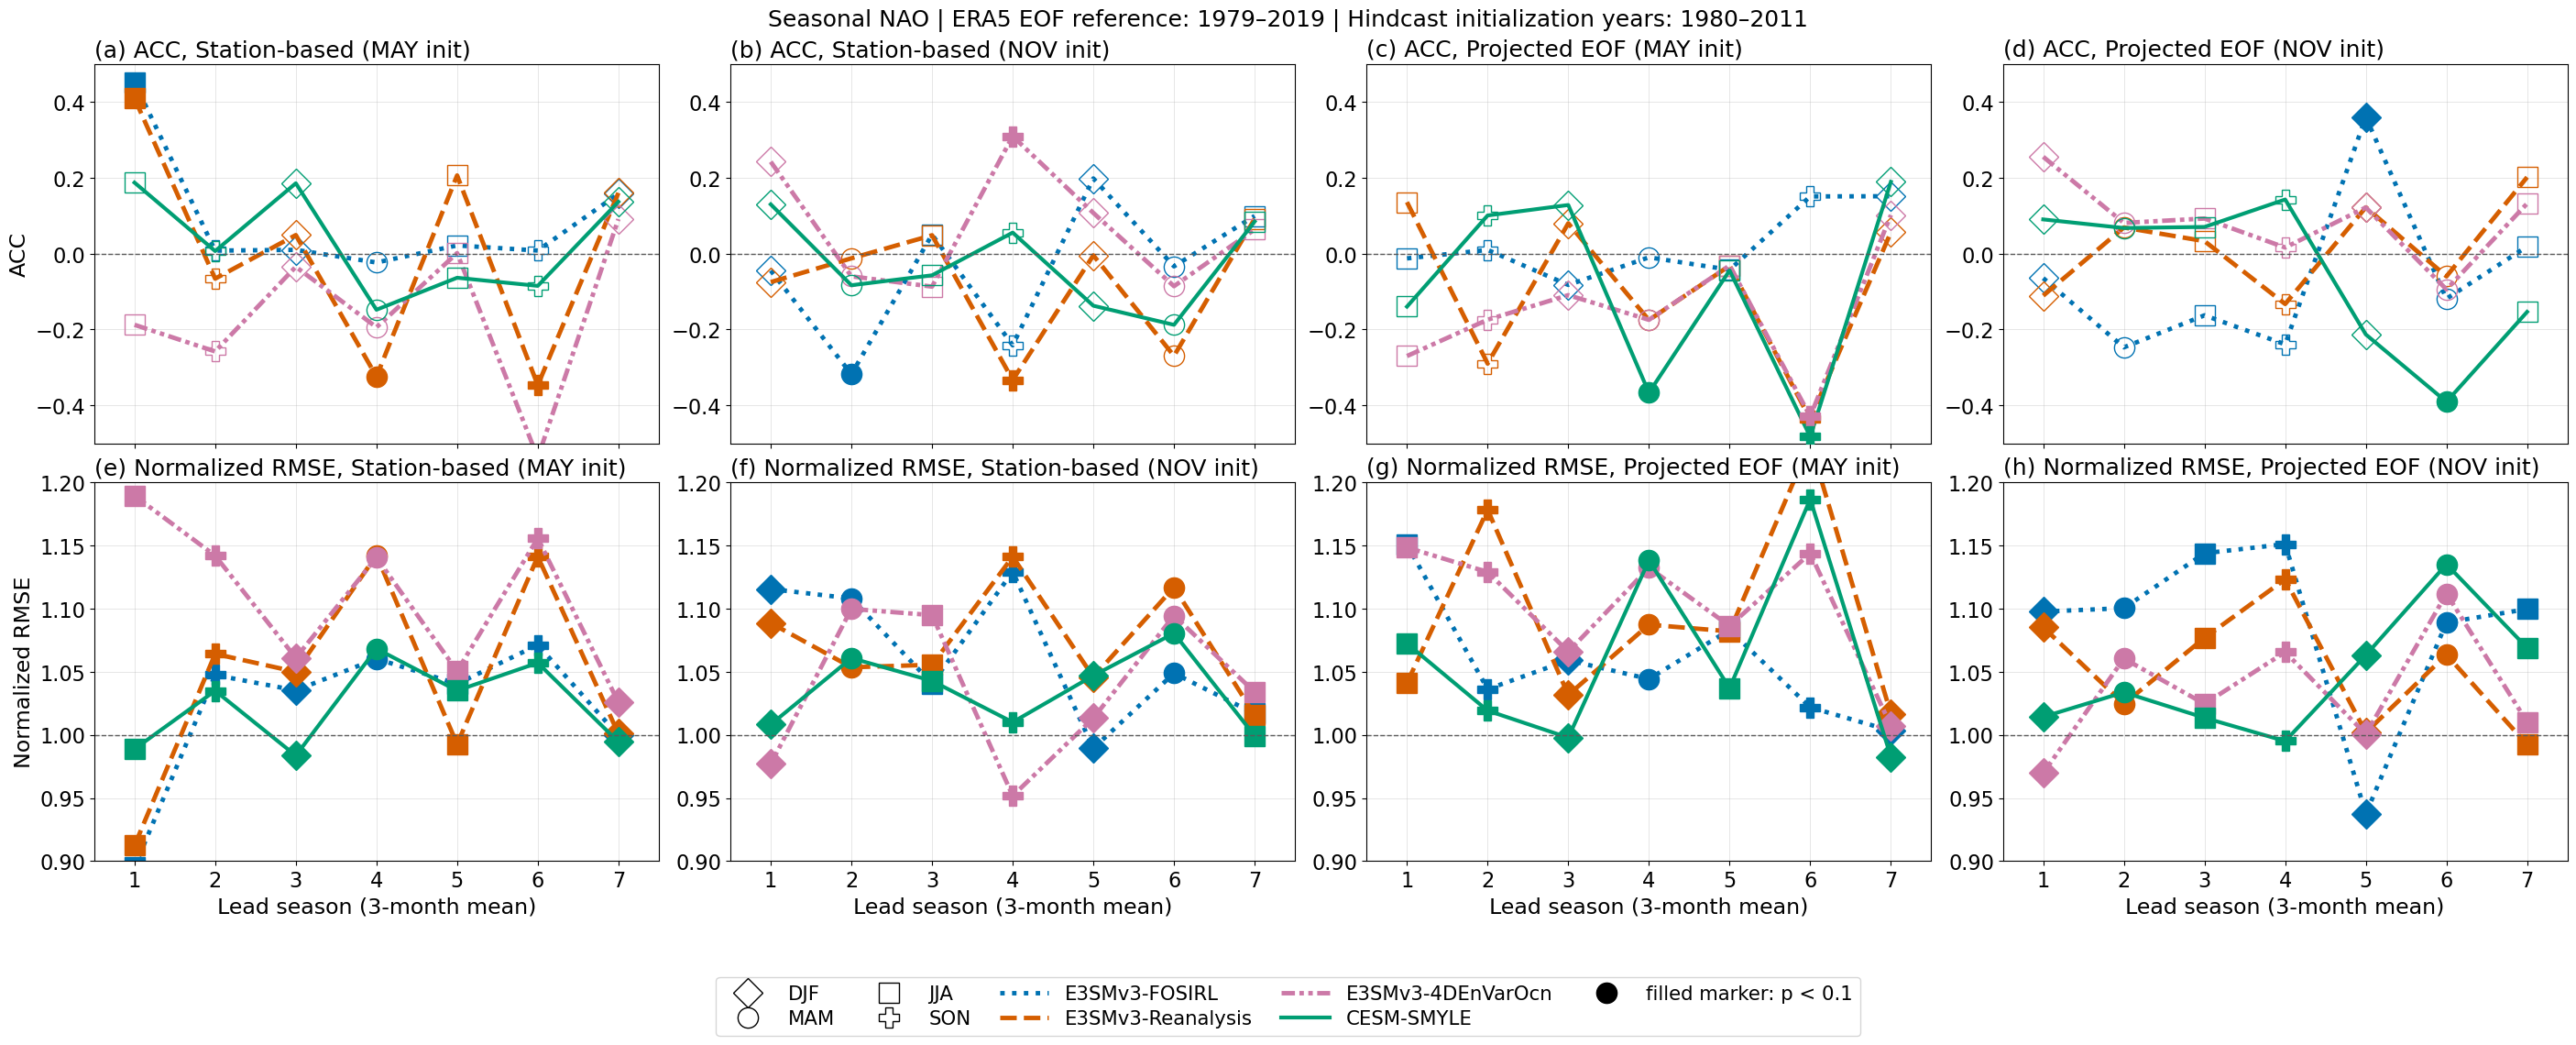

In [ ]:
import matplotlib.lines as mlines

skill_plot = FIGURE_SETUP["skill"]
nmethods = len(analysis_methods)
skill_panel_specs = [
    (method, init_month)
    for method in analysis_methods
    for init_month in init_months
]
sampled_initialization_years = set()
sample_model = models[0]
for method, init_month in skill_panel_specs:
    init_values = np.asarray(model_index[sample_model][method][init_month].Y.values)
    init_years = np.asarray([int(str(value)[:4]) for value in init_values])
    for lead, target_years in common_skill_target_years[method][init_month].items():
        target_year = np.asarray(
            model_time[sample_model][init_month].sel(L=lead).dt.year.values,
            dtype=int,
        )
        sampled_initialization_years.update(
            init_years[np.isin(target_year, np.asarray(target_years, dtype=int))].tolist()
        )
        
if not sampled_initialization_years:
    raise ValueError("No hindcast initialization years are represented in the skill figure.")

skill_init_year0 = min(sampled_initialization_years)
skill_init_year1 = max(sampled_initialization_years)
nskillcols = len(skill_panel_specs)

fig, axes = plt.subplots(
    2,
    nskillcols,
    figsize=(skill_plot.get("figsize_init_panel_width", 7.0) * nskillcols,
             skill_plot["figsize_per_column"][1]),
    sharex=True,
    constrained_layout=True,
    squeeze=False,
)

for col, (method, panel_init_month) in enumerate(skill_panel_specs):
    for row, (metric, metric_label, ylim) in enumerate(metric_specs):
        ax = axes[row, col]
        panel_label = chr(ord("a") + row * nskillcols + col)
        init_label = skill_plot.get("init_labels", {}).get(
            panel_init_month, f"Month {panel_init_month:02d} init"
        )
        ax.set_title(
            f"({panel_label}) {metric_label}, {method_titles[method]} ({init_label})",
            loc="left",
            fontsize=fontz * skill_plot["panel_title_scale"],
            pad=skill_plot["title_pad"],
        )

        for model in models:
            for init_month in (panel_init_month,):
                ds = skill[model][method][init_month]
                lead_season = np.arange(1, ds.sizes["L"] + 1)
                default_model_colors = {"E3SM-FOSIRL": "#0072B2", "E3SM-Reanalysis": "#D55E00", "E3SM-4DEnVarOcn": "#CC79A7", "SMYLE": "#009E73", "NMME": "#E69F00"}
                default_model_linestyles = {"SMYLE": "-", "E3SM-FOSIRL": ":", "E3SM-Reanalysis": "--", "E3SM-4DEnVarOcn": (0, (3, 1, 1, 1, 1, 1)), "NMME": "-."}
                target_month = np.array([
                    int(
                        model_datasets[model][init_month]["target_month"].sel(L=lead).values
                        if "target_month" in model_datasets[model][init_month]
                        else model_time[model][init_month].sel(L=lead).dt.month.values[0]
                    )
                    for lead in ds.L.values
                ])
                color = skill_plot.get("model_colors", {}).get(model, default_model_colors.get(model, "tab:gray"))
                linestyle = skill_plot.get("model_linestyles", {}).get(model, default_model_linestyles.get(model, "-"))
                linewidth = skill_plot.get("model_linewidths", {}).get(model, 3.0)
                ax.plot(
                    lead_season,
                    ds[metric],
                    color=color,
                    linestyle=linestyle,
                    linewidth=linewidth,
                )

                for month, marker in skill_plot["season_markers"].items():
                    season_mask = target_month == month
                    if not season_mask.any():
                        continue
                    if metric == "corr":
                        pvalues = np.asarray(ds.pval.values, dtype=float)
                        significant = (
                            season_mask
                            & np.isfinite(pvalues)
                            & (pvalues < significance_level)
                        )
                        nonsignificant = season_mask & ~significant
                        if nonsignificant.any():
                            ax.plot(
                                lead_season[nonsignificant],
                                ds[metric].values[nonsignificant],
                                color=color,
                                marker=marker,
                                markersize=skill_plot["marker_size"],
                                linestyle="none",
                                markerfacecolor="none",
                            )
                        if significant.any():
                            ax.plot(
                                lead_season[significant],
                                ds[metric].values[significant],
                                color=color,
                                marker=marker,
                                markersize=skill_plot["marker_size"],
                                linestyle="none",
                                markerfacecolor=color,
                                zorder=skill_plot["significance_zorder"],
                            )
                    else:
                        ax.plot(
                            lead_season[season_mask],
                            ds[metric].values[season_mask],
                            color=color,
                            marker=marker,
                            markersize=skill_plot["marker_size"],
                            linestyle="none",
                            markerfacecolor=color,
                        )

        ax.axhline(
            0 if metric == "corr" else 1,
            color="0.35",
            linestyle="--",
            linewidth=skill_plot["reference_linewidth"],
        )
        ax.set_xticks(lead_season_ticks)
        ax.set_xticklabels(lead_season_ticklabels)
        ax.set_xlim(*lead_season_limits)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.grid(
            True,
            alpha=skill_plot["grid_alpha"],
            linewidth=skill_plot["grid_linewidth"],
        )
        if col == 0:
            ax.set_ylabel(
                metric_label,
                fontsize=fontz * skill_plot["axis_label_scale"],
            )
        ax.tick_params(labelsize=fontz * skill_plot["tick_label_scale"])
        if row == 1:
            ax.set_xlabel(
                "Lead season (3-month mean)",
                fontsize=fontz * skill_plot["axis_label_scale"],
            )

default_model_colors = {"E3SM-FOSIRL": "#0072B2", "E3SM-Reanalysis": "#D55E00", "E3SM-4DEnVarOcn": "#CC79A7", "SMYLE": "#009E73", "NMME": "#E69F00"}
default_model_linestyles = {"SMYLE": "-", "E3SM-FOSIRL": ":", "E3SM-Reanalysis": "--", "E3SM-4DEnVarOcn": (0, (3, 1, 1, 1, 1, 1)), "NMME": "-."}
model_handles = [
    mlines.Line2D(
        [], [],
        color=skill_plot.get("model_colors", {}).get(model, default_model_colors.get(model, "tab:gray")),
        linestyle=skill_plot.get("model_linestyles", {}).get(model, default_model_linestyles.get(model, "-")),
        linewidth=skill_plot.get("model_linewidths", {}).get(model, 3.0),
        label=model_display_names.get(model, model),
    )
    for model in models
]
season_handles = [
    mlines.Line2D(
        [], [],
        color="black",
        marker=marker,
        markersize=skill_plot["marker_size"],
        linestyle="none",
        fillstyle="none",
        label=skill_plot["season_labels"][month],
    )
    for month, marker in skill_plot["season_markers"].items()
]
significance_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    markersize=skill_plot["marker_size"],
    linestyle="none",
    markerfacecolor="black",
    label=f"filled marker: p < {significance_level:g}",
)

legend_handles = (
    season_handles
    + model_handles
    + [significance_handle]
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=skill_plot["legend_columns"],
    fontsize=fontz * skill_plot["legend_font_scale"],
    frameon=skill_plot["legend_frameon"],
    handlelength=skill_plot["legend_handle_length"],
    columnspacing=skill_plot["legend_column_spacing"],
    labelspacing=skill_plot["legend_label_spacing"],
)

fig.suptitle(
    f"Seasonal {selected_mode} | "
    f"{reference_product} EOF reference: {eof_reference_year0}–{eof_reference_year1} | "
    f"Hindcast initialization years: {skill_init_year0}–{skill_init_year1}",
    fontsize=fontz * skill_plot["suptitle_scale"],
    linespacing=skill_plot["suptitle_linespacing"],
)
figpath = FIGURE_OUTDIR / mov.figure_filename(selected_mode, "skill")
mov.save_figure(
    fig, figpath,
    mode=selected_mode,
    metric="skill",
    title=f"Seasonal {selected_mode} Skill",
    caption=(
        f"ACC and NRMSE using lead-specific common target-year samples; "
        f"hindcast initialization years used {skill_init_year0}\u2013{skill_init_year1}; "
        f"EOF reference {eof_reference_year0}\u2013{eof_reference_year1}; "
        f"{climy0}\u2013{climy1} anomaly baseline, {reference_product} reference"
    ),
    dpi=figure_dpi,
    reference=reference_product,
)
print(figpath)
plt.show()


## PC Time-Series Diagnostics


/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nao_pc_time_series.png


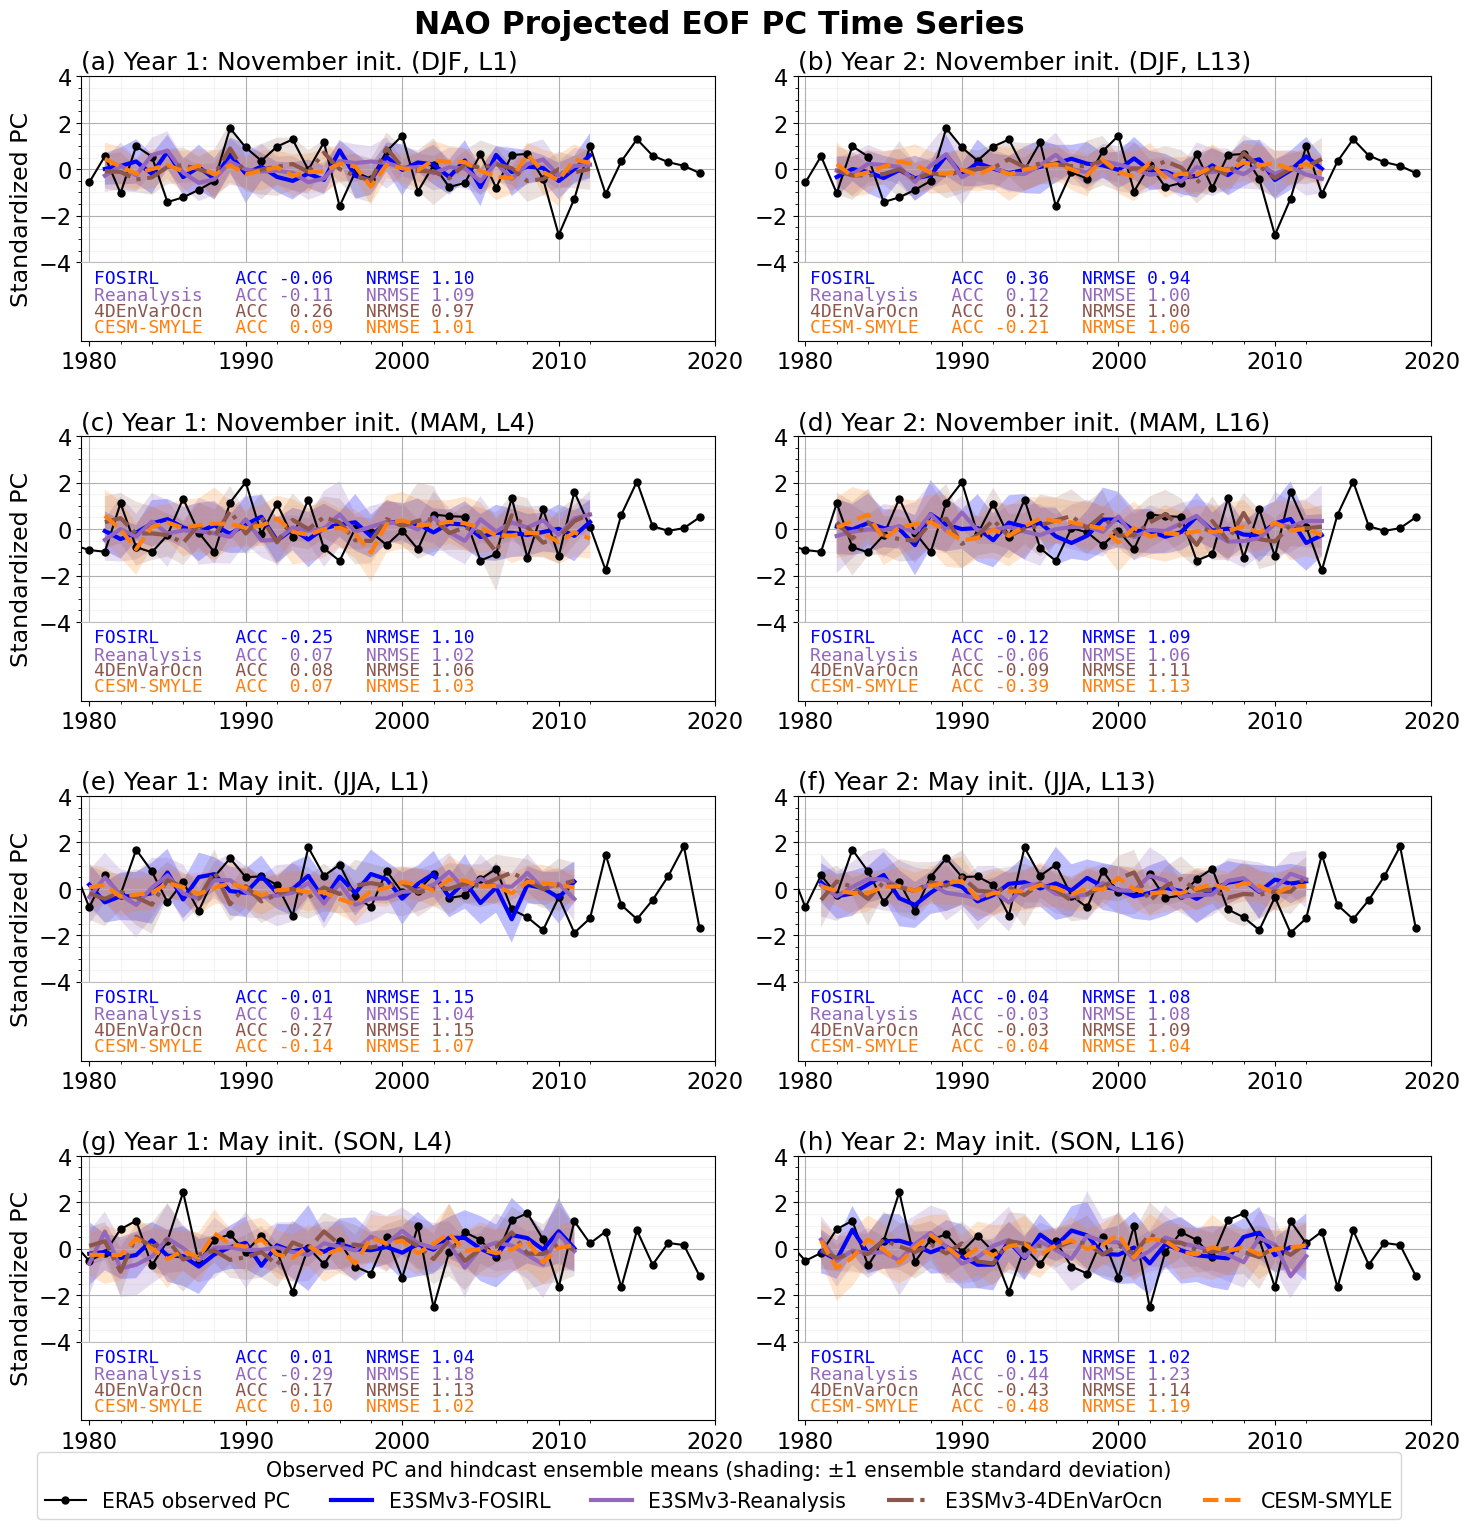

In [ ]:
# -----------------------------
# Plot projected EOF PC time series
# -----------------------------
def _time_part_values(time_da, part, drop_missing=False):
    values = np.asarray(time_da.values).ravel()
    out = []

    for t in values:
        value = np.nan
        try:
            if t is not None:
                if hasattr(t, part):
                    value = getattr(t, part)
                else:
                    ts = pd.Timestamp(t)
                    if not pd.isna(ts):
                        value = getattr(ts, part)
        except (TypeError, ValueError, OverflowError):
            value = np.nan

        out.append(value)

    arr = np.asarray(out, dtype=float)
    if drop_missing:
        arr = arr[np.isfinite(arr)]
    return arr


def _year_values(time_da):
    return _time_part_values(time_da, "year")


def _month_values(time_da):
    return _time_part_values(time_da, "month")


def _member_dim(data_array):
    for candidate in ("M", "member", "ensemble"):
        if candidate in data_array.dims:
            return candidate
    return None


def _obs_pc_for_target_month(obs_da, target_month):
    if "time" not in obs_da.dims:
        raise ValueError("Observed PC series must include a time dimension.")

    month_values = _month_values(obs_da["time"])
    valid = np.isfinite(month_values)
    valid[valid] = month_values[valid].astype(int) == int(target_month)
    obs_series = obs_da.isel(time=valid)
    obs_years = _year_values(obs_series["time"])
    obs_valid_years = np.isfinite(obs_years)
    obs_series = obs_series.isel(time=obs_valid_years)
    obs_years = obs_years[obs_valid_years].astype(int)
    return obs_series.assign_coords(time=("time", obs_years))


def _plot_model_pc_panel(
    ax,
    model,
    init_month,
    lead,
    target_month,
    color,
    linestyle,
    label,
    annotation_label,
    spread_alpha,
    annotation_xy,
):
    data = model_index[model][pc_method][init_month].sel(L=lead)
    valid_time = model_time[model][init_month].sel(L=lead)
    years = _year_values(valid_time)
    valid = np.isfinite(years)
    years = years[valid]
    data = data.isel(Y=valid)

    months = _month_values(valid_time.isel(Y=valid))
    months = months[np.isfinite(months)]
    if months.size and not np.all(months.astype(int) == int(target_month)):
        raise ValueError(
            f"Expected target month {target_month} for {model} init={init_month}, "
            f"L={lead}; found months {np.unique(months.astype(int))}"
        )

    member_dim = _member_dim(data)
    if member_dim is not None:
        data_mean = data.mean(member_dim)
        data_std = data.std(member_dim)
    else:
        data_mean = data
        data_std = xr.zeros_like(data)

    ax.plot(
        years,
        data_mean,
        color=color,
        linewidth=pc_line_width,
        linestyle=linestyle,
        label=label,
    )
    ax.fill_between(
        years,
        (data_mean - data_std).values,
        (data_mean + data_std).values,
        fc=color,
        alpha=spread_alpha,
    )

    if lead in skill[model][pc_method][init_month].L.values:
        skill_row = skill[model][pc_method][init_month].sel(L=lead)
        if annotation_xy is not None:
            txt = ax.text(
                *annotation_xy,
                f"{annotation_label:<11}  ACC {float(skill_row.corr): .2f}   NRMSE {float(skill_row.rmse):.2f}",
                transform=ax.transAxes,
                fontsize=pc_annotation_fontz,
                fontfamily="monospace",
                color=color,
                bbox=pc_annotation_box,
                zorder=8,
            )
            txt.set_in_layout(False)

# This mirrors the DJF Niño3.4 time-series layout: observations in black,
# model mean/spread and benchmarks configured in FIGURE_SETUP["pc_time_series"].
pc_method = "eof"
pc_settings = FIGURE_SETUP["pc_time_series"]

# Dynamically determine which initialization months are available across models
pc_startmonths_plot = [
    month for month in init_months
    if any(
        model in model_index
        and pc_method in model_index[model]
        and month in model_index[model][pc_method]
        for model in models
    )
]

if not pc_startmonths_plot:
    raise ValueError("No requested initialization months are available for PC plotting.")

pc_ncol = 2
pc_fontz = fontz
pc_scales = pc_settings.get("fontsize_scales", {})
pc_title_fontz = pc_fontz * pc_scales.get("title", 1.05)
pc_tick_fontz = pc_fontz * pc_scales.get("tick", 0.9)
pc_legend_fontz = pc_fontz * pc_scales.get("legend", 0.9)
pc_annotation_fontz = pc_fontz * pc_scales.get("annotation", 0.9)

pc_fig_width = pc_settings.get("figsize_width", 14.0)
pc_row_height = pc_settings.get("figsize_row_height", 3.6)
pc_line_width = pc_settings.get("line_width", 3.0)
pc_obs_marker_size = pc_settings.get("obs_marker_size", 10)
pc_grid_minor_alpha = pc_settings.get("grid_minor_alpha", 0.15)
pc_annotation_box = pc_settings.get("annotation_box", dict(facecolor="white", alpha=0.65, edgecolor="none"))

pc_data_ylim = pc_settings.get("plot_ylim", [-4.0, 4.0])
pc_annotation_band_height = pc_settings.get("annotation_band_height", 0.0)
pc_plot_ylim = [pc_data_ylim[0] - pc_annotation_band_height, pc_data_ylim[1]]
pc_major_yticks = pc_settings.get("major_yticks", [-4, -2, 0, 2, 4])
minor_step = pc_settings.get("minor_yticks_step", 0.5)
pc_minor_yticks = np.arange(pc_data_ylim[0] + minor_step, pc_data_ylim[1], minor_step)

pc_target_year_min = min(
    int(ds.target_year_start.min())
    for model in models for method in analysis_methods
    for ds in skill[model][method].values()
)
pc_target_year_max = max(
    int(ds.target_year_end.max())
    for model in models for method in analysis_methods
    for ds in skill[model][method].values()
)
pc_plot_xmin = pc_target_year_min - 0.5
pc_plot_xmax = pc_target_year_max + 0.5
pc_major_year_step = pc_settings.get("major_year_step", 10)
pc_minor_year_step = pc_settings.get("minor_year_step", 2)
pc_major_years = np.arange(
    int(np.ceil(pc_target_year_min / pc_major_year_step) * pc_major_year_step),
    pc_target_year_max + pc_major_year_step,
    pc_major_year_step,
)
pc_minor_years = np.arange(pc_target_year_min, pc_target_year_max + 1, pc_minor_year_step)

pc_hindcast_label = pc_settings.get("hindcast_label", {11: "November init.", 5: "May init."})
pc_hindcast_color = pc_settings.get("hindcast_color", {11: "g", 5: "b"})
pc_obs_color = pc_settings.get("obs_color", "k")
pc_target_season_labels = pc_settings.get("target_season_labels", {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"})

plt.rcParams.update({
    "font.size": pc_fontz,
    "axes.titlesize": pc_title_fontz,
    "xtick.labelsize": pc_tick_fontz,
    "ytick.labelsize": pc_tick_fontz,
    "legend.fontsize": pc_legend_fontz,
})

# Select the 8 cases consistent with EOF patterns:
pattern_years = FIGURE_SETUP["eof_patterns"].get("pattern_years", (1, 2))
pattern_seasons = FIGURE_SETUP["eof_patterns"].get("pattern_seasons", ("DJF", "MAM", "JJA", "SON"))
preferred_init_by_season = FIGURE_SETUP["eof_patterns"].get("preferred_init_by_season", {
    "DJF": 11,
    "MAM": 11,
    "JJA": 5,
    "SON": 5,
})

# Let's gather all available (init_month, lead, target_year, target_season, target_month)
available_cases = []
for init_month in pc_startmonths_plot:
    ref_model = None
    for m in models:
        if m in model_index and pc_method in model_index[m] and init_month in model_index[m][pc_method]:
            ref_model = m
            break
    if ref_model is None:
        continue
    
    ref_ds = model_index[ref_model][pc_method][init_month]
    for lead_val in ref_ds.L.values:
        lead = int(lead_val)
        display_lead = lead - 2
        
        target_month = int(model_time[ref_model][init_month].sel(L=lead).dt.month.values[0])
        target_season = pc_target_season_labels.get(target_month, f"month {target_month:02d}")
        target_year = mov.target_year_from_display_lead(display_lead)
        
        available_cases.append({
            "init_month": init_month,
            "lead": lead,
            "display_lead": display_lead,
            "target_year": target_year,
            "target_month": target_month,
            "target_season": target_season,
        })

# 4 rows and 2 columns: column is year, row is season
pc_cases = []
for target_season in pattern_seasons:
    for target_year in pattern_years:
        candidates = [
            c for c in available_cases
            if c["target_year"] == target_year and c["target_season"] == target_season
        ]
        if not candidates:
            continue
        preferred_init = preferred_init_by_season.get(target_season)
        candidates = sorted(
            candidates,
            key=lambda c: (
                c["init_month"] != preferred_init,
                c["display_lead"],
                c["init_month"],
            )
        )
        pc_cases.append(candidates[0])

if not pc_cases:
    raise ValueError("No PC time series cases were selected.")

pc_ncol = 2
pc_nrow = max(1, int(np.ceil(len(pc_cases) / pc_ncol)))
fig = plt.figure(figsize=(pc_fig_width, pc_row_height * pc_nrow))
fig.suptitle(
    f"{selected_mode} Projected EOF PC Time Series",
    fontsize=pc_fontz * pc_settings.get("suptitle_scale", 1.25),
    fontweight="bold",
    y=pc_settings.get("suptitle_y", 0.972),
)
pc_panel_index = 0

for idx, case in enumerate(pc_cases):
    row = idx // pc_ncol
    col = idx % pc_ncol

    init_month = case["init_month"]
    lead = case["lead"]
    display_lead = case["display_lead"]
    target_month = case["target_month"]
    target_season = case["target_season"]
    target_year = case["target_year"]
    
    ax = fig.add_subplot(pc_nrow, pc_ncol, idx + 1)
    pc_panel_index += 1
    panel_label = f"({chr(ord('a') + pc_panel_index - 1)})"

    ax.set_ylim(pc_plot_ylim)
    ax.set_yticks(pc_major_yticks)
    ax.set_yticks(pc_minor_yticks, minor=True)
    ax.set_xlim([pc_plot_xmin, pc_plot_xmax])
    ax.set_xticks(pc_major_years)
    ax.set_xticks(pc_minor_years, minor=True)
    ax.tick_params(axis="both", labelsize=pc_tick_fontz, direction=pc_settings.get("tick_direction", "out"))
    ax.grid(True, which="major")
    ax.grid(True, which="minor", alpha=pc_grid_minor_alpha)

    if pc_annotation_band_height > 0:
        ax.axhspan(
            pc_plot_ylim[0],
            pc_data_ylim[0],
            facecolor=pc_settings.get("annotation_band_facecolor", "white"),
            alpha=pc_settings.get("annotation_band_alpha", 1.0),
            edgecolor="none",
            zorder=2,
        )
        ax.axhline(
            pc_data_ylim[0],
            color=pc_settings.get("annotation_band_edgecolor", "0.75"),
            linewidth=0.8,
            zorder=3,
        )

    # Title
    title = (
        f"{panel_label} Year {target_year}: {pc_hindcast_label.get(init_month, init_month)} "
        f"({target_season}, L{display_lead})"
    )
    ax.set_title(title, loc="left", fontsize=pc_title_fontz, pad=5)

    if col == 0:
        ax.set_ylabel(pc_settings.get("ylabel_text", "Standardized PC"), fontsize=pc_fontz * 0.95)

    obs_pc = _obs_pc_for_target_month(obs_index[pc_method], target_month)
    ax.plot(
        obs_pc.time,
        obs_pc,
        color=pc_obs_color,
        marker=".",
        markersize=pc_obs_marker_size,
        label=f"{reference_product} observed PC",
    )

    # Plot all models dynamically based on custom styles
    for model in models:
        if (
            model in model_index
            and pc_method in model_index[model]
            and init_month in model_index[model][pc_method]
            and lead in model_index[model][pc_method][init_month].L.values
        ):
            m_style = pc_settings["model_styles"].get(model, {})
            label = m_style.get("label", model)
            annotation_label = m_style.get("annotation_label", label)
            linestyle = m_style.get("linestyle", "-")
            spread_alpha = m_style.get("spread_alpha", 0.15)
            annotation_xy = m_style.get("annotation_xy", None)

            color_cfg = m_style.get("colors")
            if isinstance(color_cfg, dict):
                color = color_cfg.get(init_month, "tab:blue")
            elif isinstance(color_cfg, str):
                color = color_cfg
            else:
                color = pc_hindcast_color.get(init_month, "tab:blue")

            _plot_model_pc_panel(
                ax,
                model,
                init_month,
                lead,
                target_month,
                color,
                linestyle,
                label,
                annotation_label,
                spread_alpha,
                annotation_xy,
            )

fig.subplots_adjust(
    left=pc_settings.get("subplot_left", 0.075),
    right=pc_settings.get("subplot_right", 0.975),
    top=pc_settings.get("subplot_top", 0.930),
    bottom=pc_settings.get("subplot_bottom", 0.090),
    wspace=pc_settings.get("subplot_wspace", 0.13),
    hspace=pc_settings.get("subplot_hspace", 0.36),
)

# Global legend at the bottom of the figure on a single line with a frame box
legend_handles = [
    mlines.Line2D(
        [], [],
        color=pc_obs_color,
        marker=".",
        markersize=pc_obs_marker_size,
        linestyle="-",
        label=f"{reference_product} observed PC",
    )
]
for model in models:
    m_style = pc_settings.get("model_styles", {}).get(model, {})
    label = m_style.get("label", model_display_names.get(model, model))
    linestyle = m_style.get("linestyle", "-")
    color_cfg = m_style.get("colors")
    if isinstance(color_cfg, str):
        m_color = color_cfg
    elif isinstance(color_cfg, dict):
        m_color = next(iter(color_cfg.values()), "tab:blue")
    else:
        m_color = "tab:blue"
    legend_handles.append(
        mlines.Line2D(
            [], [],
            color=m_color,
            linewidth=pc_line_width,
            linestyle=linestyle,
            label=label,
        )
    )

fig.legend(
    handles=legend_handles,
    loc=pc_settings.get("legend_loc", "lower center"),
    ncol=pc_settings.get("legend_ncol", min(5, len(legend_handles))),
    bbox_to_anchor=pc_settings.get("legend_bbox_to_anchor", (0.5, 0.022)),
    fontsize=pc_legend_fontz,
    frameon=pc_settings.get("legend_frameon", True),
    title="Observed PC and hindcast ensemble means (shading: ±1 ensemble standard deviation)",
    title_fontsize=pc_legend_fontz,
)
figpath = FIGURE_OUTDIR / mov.figure_filename(selected_mode, "pc_time_series")
mov.save_figure(
    fig,
    figpath,
    mode=selected_mode,
    metric="pc_time_series",
    title=f"{selected_mode} Projected EOF PC Time Series",
    caption=(
        f"Projected EOF PC time series for hindcasts initialized "
        f"{hindcast_init_year0}-{hindcast_init_year1}; EOF reference "
        f"{eof_reference_year0}-{eof_reference_year1}; "
        f"{climy0}-{climy1} anomaly baseline, {reference_product} reference"
    ),
    dpi=figure_dpi,
    reference=reference_product,
)
print(figpath)
plt.show()


## Export Compact Numeric Backup


In [ ]:
summary_rows = []
for model in models:
    for method in analysis_methods:
        for init_month in init_months:
            dataset = skill[model][method][init_month]
            for lead in dataset.L.values:
                target_month_value = int(
                    model_time[model][init_month].sel(L=lead).dt.month.values[0]
                )
                north_separated = (
                    bool(obs_dataset["mode_north_separated_from_next"].sel(
                        target_month=target_month_value
                    ))
                    if "mode_north_separated_from_next" in obs_dataset
                    else np.nan
                )
                summary_rows.append(
                    {
                        "mode": selected_mode,
                        "model": model,
                        "method": method,
                        "init_month": init_month,
                        "lead": int(lead),
                        "target_month": target_month_value,
                        "hindcast_initialization_start_year": hindcast_init_year0,
                        "hindcast_initialization_end_year": hindcast_init_year1,
                        "target_year_start": int(dataset["target_year_start"].sel(L=lead)),
                        "target_year_end": int(dataset["target_year_end"].sel(L=lead)),
                        "sample_count": int(dataset["sample_count"].sel(L=lead)),
                        "reference_north_separated_from_next": north_separated,
                        "potentially_mode_mixed": bool(not north_separated) if pd.notna(north_separated) else np.nan,
                        "anomaly_climatology_start_year": climy0,
                        "anomaly_climatology_end_year": climy1,
                        "eof_reference_start_year": eof_reference_year0,
                        "eof_reference_end_year": eof_reference_year1,
                        "acc": float(dataset["corr"].sel(L=lead)),
                        "pval": float(dataset["pval"].sel(L=lead)),
                        "nrmse": float(dataset["rmse"].sel(L=lead)),
                    }
                )

summary_df = pd.DataFrame(summary_rows)
summary_df[f"significant_p_lt_{significance_level:g}"] = (
    summary_df["pval"] < significance_level
)

if write_summary_tables:
    table_outdir.mkdir(parents=True, exist_ok=True)
    stem = (
        f"{selected_mode.lower()}_multimodel_skill_eofref{eof_reference_year0}_{eof_reference_year1}_"
        f"init{hindcast_init_year0}_{hindcast_init_year1}_common_by_lead_clim{climy0}_{climy1}"
    )
    csv_path = table_outdir / f"{stem}.csv"
    txt_path = table_outdir / f"{stem}.txt"
    summary_df.to_csv(csv_path, index=False, float_format="%.4f")
    txt_path.write_text(
        summary_df.to_string(
            index=False, float_format=lambda value: f"{value:.4f}"
        )
    )
    print(csv_path)
    print(txt_path)

summary_df.head(12)


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/nao_multimodel_skill_eofref1979_2019_init1980_2011_common_by_lead_clim1981_2010.csv
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/nao_multimodel_skill_eofref1979_2019_init1980_2011_common_by_lead_clim1981_2010.txt


,mode,model,method,init_month,lead,target_month,hindcast_initialization_start_year,hindcast_initialization_end_year,target_year_start,target_year_end,...,reference_north_separated_from_next,potentially_mode_mixed,anomaly_climatology_start_year,anomaly_climatology_end_year,eof_reference_start_year,eof_reference_end_year,acc,pval,nrmse,significant_p_lt_0.1
0,NAO,E3SM-FOSIRL,station,5,3,7,1980,2011,1980,2011,...,True,False,1981,2010,1979,2019,0.451571,0.010772,0.895355,True
1,NAO,E3SM-FOSIRL,station,5,6,10,1980,2011,1980,2011,...,False,True,1981,2010,1979,2019,0.007885,0.966421,1.047227,False
2,NAO,E3SM-FOSIRL,station,5,9,1,1980,2011,1981,2012,...,True,False,1981,2010,1979,2019,0.009880,0.957200,1.035112,False
3,NAO,E3SM-FOSIRL,station,5,12,4,1980,2011,1981,2012,...,True,False,1981,2010,1979,2019,-0.023439,0.907619,1.060129,False
4,NAO,E3SM-FOSIRL,station,5,15,7,1980,2011,1981,2012,...,True,False,1981,2010,1979,2019,0.021470,0.910339,1.040233,False
5,NAO,E3SM-FOSIRL,station,5,18,10,1980,2011,1981,2012,...,False,True,1981,2010,1979,2019,0.008068,0.965045,1.071073,False
6,NAO,E3SM-FOSIRL,station,5,21,1,1980,2011,1982,2013,...,True,False,1981,2010,1979,2019,0.157648,0.388842,0.999431,False
7,NAO,E3SM-FOSIRL,station,11,3,1,1980,2011,1981,2012,...,True,False,1981,2010,1979,2019,-0.044744,0.807882,1.115255,False
8,NAO,E3SM-FOSIRL,station,11,6,4,1980,2011,1981,2012,...,True,False,1981,2010,1979,2019,-0.318043,0.099078,1.107837,True
9,NAO,E3SM-FOSIRL,station,11,9,7,1980,2011,1981,2012,...,True,False,1981,2010,1979,2019,0.050064,0.785540,1.040520,False


## PCMDI EOF Pattern Diagnostics


In [ ]:
def model_pattern_variable(dataset):
    return "mode_pattern"


def pattern_significance_for_plot(dataset, selector, *, is_reference=False):
    return mov.pattern_significance(
        dataset,
        selector,
        allow_regression=not is_reference,
        eof_bootstrap_confidence=eof_bootstrap_confidence,
    )


def build_pattern_cases(*, include_all_initializations=False):
    available = []

    for init_month in init_months:
        reference_dataset = model_datasets[pattern_model_order[0]][init_month]

        for lead_value in reference_dataset["mode_pattern"].L.values:
            lead = int(lead_value)
            display_lead = lead - 2

            target_months = {
                model: int(
                    model_datasets[model][init_month]["target_month"].sel(L=lead)
                )
                for model in pattern_model_order
                if lead in set(map(
                    int, model_datasets[model][init_month]["mode_pattern"].L.values
                ))
            }

            if len(set(target_months.values())) != 1:
                raise ValueError(
                    f"Target-month mismatch for init {init_month:02d}, "
                    f"lead {lead}: {target_months}"
                )

            target_month = next(iter(target_months.values()))
            target_season = target_seasons.get(target_month, month_names[target_month])

            available.append(
                {
                    "init_month": init_month,
                    "lead": lead,
                    "display_lead": display_lead,
                    "target_year": mov.target_year_from_display_lead(display_lead),
                    "target_month": target_month,
                    "target_season": target_season,
                }
            )

    selected = []

    for target_year in eof_plot["pattern_years"]:
        for target_season in eof_plot["pattern_seasons"]:
            candidates = [
                case
                for case in available
                if case["target_year"] == target_year
                and case["target_season"] == target_season
            ]

            if not candidates:
                print(f"No pattern panel available for year {target_year} {target_season}.")
                continue

            if include_all_initializations:
                for init_month in init_months:
                    init_candidates = [
                        case for case in candidates
                        if case["init_month"] == init_month
                    ]
                    if not init_candidates:
                        print(
                            f"No pattern panel available for year {target_year} "
                            f"{target_season}, {month_names[init_month]} init."
                        )
                        continue
                    selected.append(
                        min(init_candidates, key=lambda case: case["display_lead"])
                    )
                continue

            preferred_init = eof_plot["preferred_init_by_season"].get(target_season)

            candidates = sorted(
                candidates,
                key=lambda case: (
                    case["init_month"] != preferred_init,
                    case["display_lead"],
                    case["init_month"],
                ),
            )

            selected.append(candidates[0])

    return selected


EOF map pattern variable: mode_pattern (regional EOF-domain maps)
Using atlantic map projection for NAO panels.
/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nao_eof_patterns_year1.png


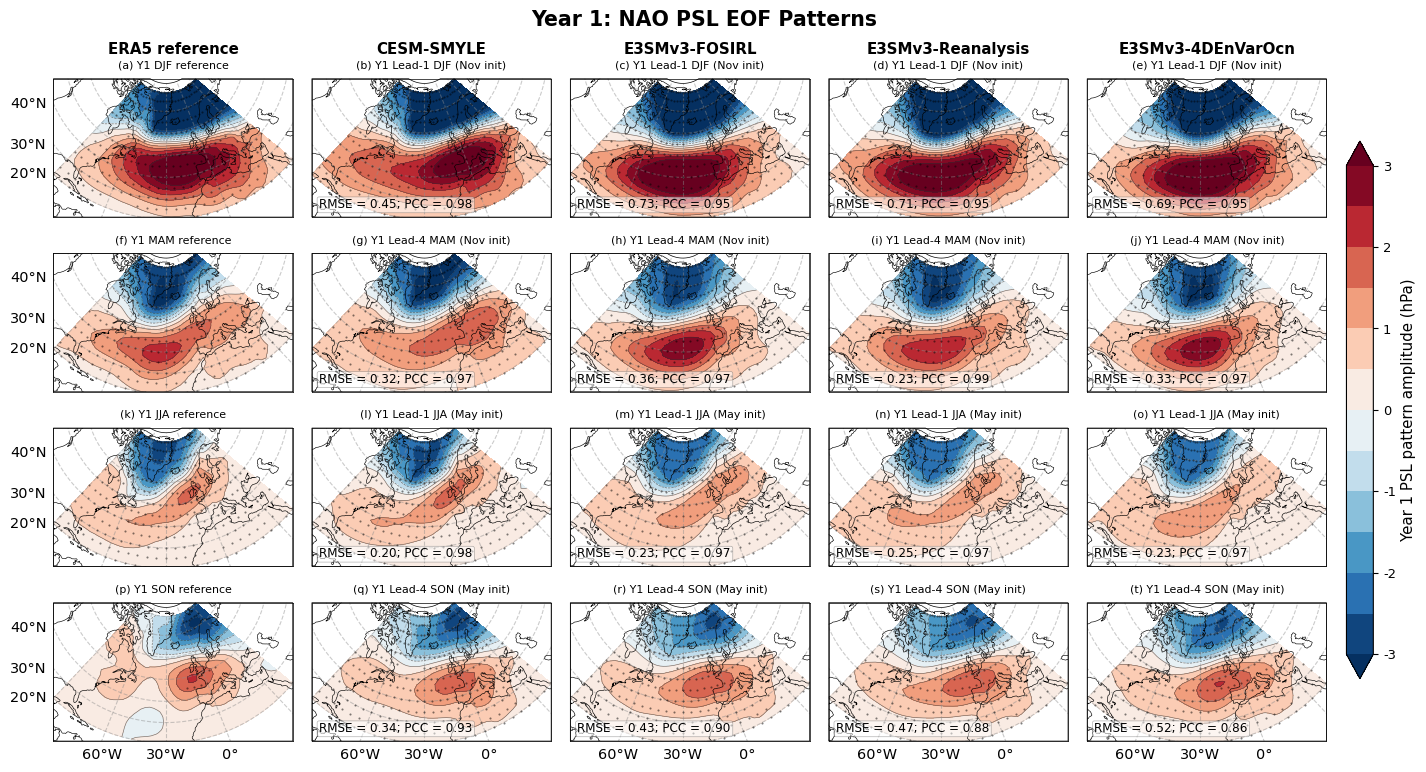

/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nao_eof_patterns_year2.png


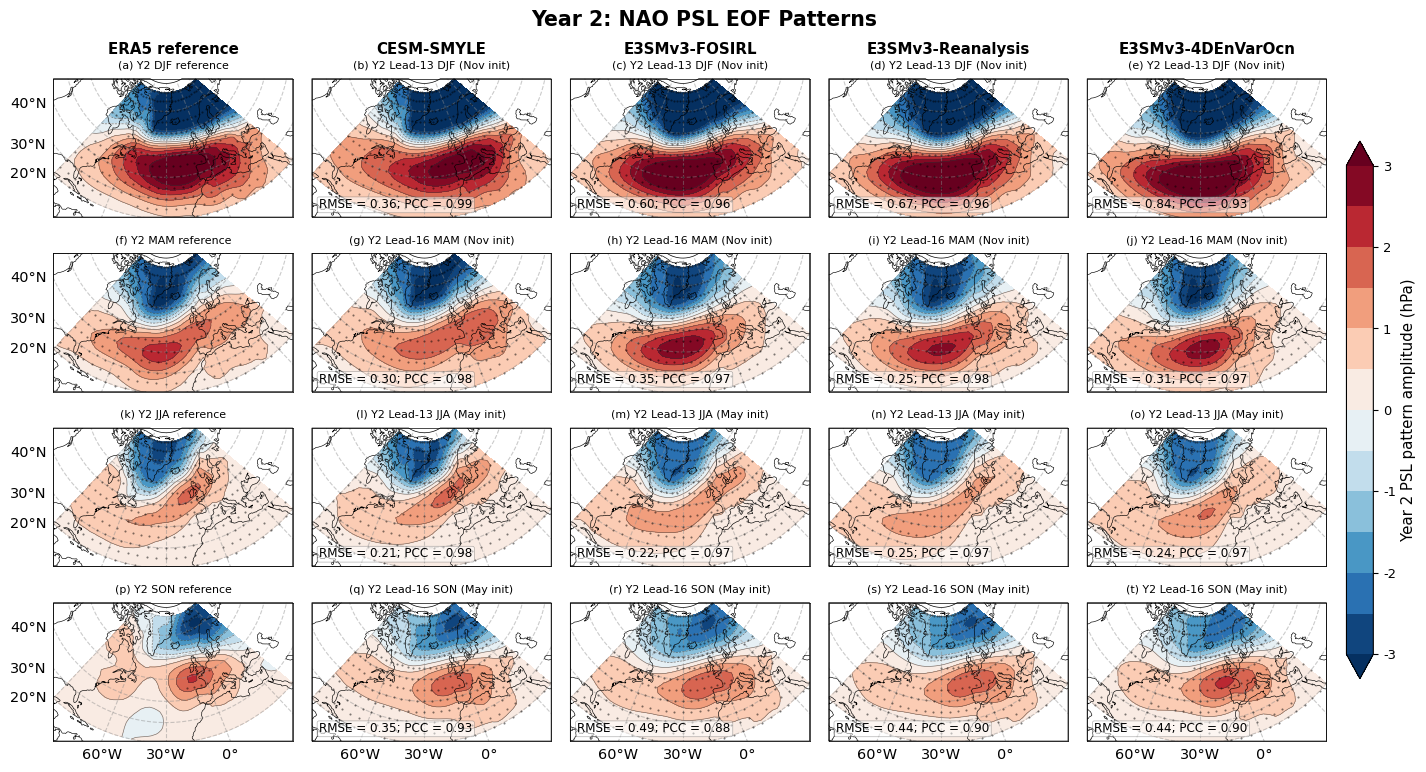

In [ ]:
eof_plot = FIGURE_SETUP["eof_patterns"]

# ---------------------------------------------------------------------
# Derived font sizes for EOF-pattern figure
# ---------------------------------------------------------------------
year_section_title_fontsize = fontz * eof_plot.get("year_section_title_scale", 0.90)
column_header_fontsize = fontz * eof_plot.get("column_header_scale", 0.85)
panel_title_fontsize = fontz * eof_plot.get("panel_title_scale", 0.60)
metric_box_fontsize = fontz * eof_plot.get("metric_box_font_scale", 0.62)
map_label_fontsize = fontz * eof_plot.get("map_label_scale", 0.45)
axis_label_fontsize = fontz * eof_plot.get("axis_label_scale", 0.90)
tick_label_fontsize = fontz * eof_plot.get("tick_label_scale", 0.58)
colorbar_label_fontsize = fontz * eof_plot.get("colorbar_label_scale", 0.78)
colorbar_tick_fontsize = fontz * eof_plot.get("colorbar_tick_scale", 0.66)

month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec",
}
target_seasons = {1: "DJF", 4: "MAM", 7: "JJA", 10: "SON"}
pattern_model_order = tuple(
    model
    for model in ("SMYLE", "E3SM-FOSIRL", "E3SM-Reanalysis", "E3SM-4DEnVarOcn", "NMME")
    if model in models
) or tuple(models)
column_titles = [f"{reference_product} reference"] + [
    model_display_names[model] for model in pattern_model_order
]

reference_pattern_variable = "mode_pattern"
reference_mask_variable = "mode_ocean_mask"
print("EOF map pattern variable:", reference_pattern_variable, "(regional EOF-domain maps)")

pattern_rows = []
missing_significance_panels = []
significance_sources = set()

pattern_cases = build_pattern_cases()
if not pattern_cases:
    raise ValueError("No pattern panels were selected.")

for case in pattern_cases:
    init_month = case["init_month"]
    lead = case["lead"]
    display_lead = case["display_lead"]
    target_month = case["target_month"]
    target_season = case["target_season"]
    target_year = case["target_year"]

    reference_pattern = obs_dataset[reference_pattern_variable].sel(
        target_month=target_month
    )
    plot_ocean_mask = None
    if reference_mask_variable in obs_dataset:
        plot_ocean_mask = (
            obs_dataset[reference_mask_variable]
            .sel(target_month=target_month)
            .astype(bool)
        )
        reference_pattern = mov.mask_pattern_for_plot(
            reference_pattern, plot_ocean_mask
        )

    reference_significant, significance_label = pattern_significance_for_plot(
        obs_dataset,
        {"target_month": target_month},
        is_reference=True,
    )

    if significance_label:
        significance_sources.add(significance_label)

    if reference_significant is None:
        missing_significance_panels.append(f"{reference_product} {target_season}")
    elif plot_ocean_mask is not None:
        reference_significant = (
            reference_significant.astype(bool) & plot_ocean_mask
        ).astype(bool)

    panels = [
        (
            reference_pattern,
            f"Y{target_year} {target_season} reference",
            None,
            reference_significant,
        )
    ]

    for model in pattern_model_order:
        dataset = model_datasets[model][init_month]
        model_leads = set(map(int, dataset[model_pattern_variable(dataset)].L.values))
        if lead not in model_leads:
            panels.append((None, f"{model} lead not available", None, None))
            continue
        model_pattern = dataset[model_pattern_variable(dataset)].sel(L=lead)
        model_pattern = mov.mask_pattern_for_plot(model_pattern, plot_ocean_mask)

        model_significant, significance_label = pattern_significance_for_plot(
            dataset,
            {"L": lead},
            is_reference=False,
        )

        if significance_label:
            significance_sources.add(significance_label)

        if model_significant is None:
            missing_significance_panels.append(
                f"{model} init {init_month:02d} lead {display_lead}"
            )
        elif plot_ocean_mask is not None:
            model_significant = (
                model_significant.astype(bool) & plot_ocean_mask
            ).astype(bool)

        rmse, pcc = mov.spatial_pattern_metrics(model_pattern, reference_pattern)

        if {
            "mode_pattern_rmse_reference",
            "mode_pattern_pcc_reference",
        } <= set(dataset.data_vars):
            stored_rmse = float(dataset["mode_pattern_rmse_reference"].sel(L=lead))
            stored_pcc = float(dataset["mode_pattern_pcc_reference"].sel(L=lead))

            if not np.isclose(rmse, stored_rmse, rtol=1e-3, atol=1e-3):
                warnings.warn(
                    f"Computed pattern RMSE ({rmse:.4f}) diverges from stored value ({stored_rmse:.4f}) for {model} init={init_month:02d} L={lead}"
                )
            if not np.isclose(pcc, stored_pcc, rtol=1e-3, atol=1e-3):
                warnings.warn(
                    f"Computed pattern PCC ({pcc:.4f}) diverges from stored value ({stored_pcc:.4f}) for {model} init={init_month:02d} L={lead}"
                )

        panels.append(
            (
                model_pattern,
                (
                    f"Y{target_year} Lead-{display_lead} {target_season} "
                    f"({month_names[init_month]} init)"
                ),
                (
                    f"RMSE = {rmse:.{eof_plot['rmse_decimals']}f}; "
                    f"PCC = {pcc:.{eof_plot['pcc_decimals']}f}"
                ),
                model_significant,
            )
        )

    pattern_rows.append(panels)


levels = np.asarray(eof_plot["levels"], dtype=float)
if levels.ndim != 1 or levels.size < 2 or not np.all(np.diff(levels) > 0):
    raise ValueError(
        "FIGURE_SETUP['eof_patterns']['levels'] must be a strictly "
        "increasing 1D sequence."
    )

reference_pattern = pattern_rows[0][0][0]
map_projection, map_projection_name = mov.make_projection(
    selected_mode,
    albers_projection_by_mode=ALBERS_PROJECTION_BY_MODE,
    use_cartopy=eof_plot.get("use_cartopy", True),
)
data_crs = mov.data_crs() if map_projection is not None else None
map_extent = mov.mode_extent(selected_mode, reference_pattern)

lon_limits = (
    float(reference_pattern.lon.min()),
    float(reference_pattern.lon.max()),
)
lon_ticks = np.linspace(lon_limits[0], lon_limits[1], 5)

subplot_kw = {"projection": map_projection} if map_projection is not None else {}

if map_projection is None and mov.CARTOPY_IMPORT_ERROR is not None:
    print(
        "Cartopy unavailable; using plain latitude-longitude axes:",
        mov.CARTOPY_IMPORT_ERROR,
    )
elif map_projection_name is not None:
    print(f"Using {map_projection_name} map projection for {selected_mode} panels.")

ncols = len(column_titles)
if map_projection_name in {"north_polar", "south_polar"}:
    polar_column_width = eof_plot.get("polar_column_width", 4.45)
    polar_colorbar_width = eof_plot.get("polar_colorbar_width", 1.45)
    eof_plot["figsize_width"] = max(
        eof_plot.get("figsize_width", 0),
        polar_column_width * ncols + polar_colorbar_width,
    )

fig_width = eof_plot["figsize_width"]

if missing_significance_panels:
    print("Missing significance diagnostics:", missing_significance_panels)

season_label = "/".join(eof_plot["pattern_seasons"])

for target_year in eof_plot["pattern_years"]:
    year_case_indices = [
        i for i, c in enumerate(pattern_cases)
        if c["target_year"] == target_year
    ]
    if not year_case_indices:
        continue

    nrows = len(year_case_indices)
    fig_height = max(
        eof_plot.get("figsize_min_height", 4.0),
        nrows * eof_plot.get("figsize_row_height", 3.8),
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(fig_width, fig_height),
        subplot_kw=subplot_kw,
    )
    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.expand_dims(axes, axis=0)
    elif ncols == 1:
        axes = np.expand_dims(axes, axis=1)

    fig.subplots_adjust(
        left=eof_plot.get("subplot_left", 0.06),
        right=eof_plot.get("subplot_right", 0.86),
        bottom=eof_plot.get("subplot_bottom", 0.06),
        top=eof_plot.get("subplot_top", 0.88),
        wspace=eof_plot.get("subplot_wspace", 0.70),
        hspace=eof_plot.get("subplot_hspace", 0.22),
    )

    fig.suptitle(
        f"Year {target_year}: {selected_mode} {source_field} EOF Patterns",
        fontsize=suptitle_fontsize,
        fontweight="bold",
        y=eof_plot.get("suptitle_y", 0.98),
    )

    # Column titles above top row
    for col, title in enumerate(column_titles):
        col_x_shift = eof_plot.get("column_header_shift_by_col", {}).get(col, 0.0)
        col_y_shift = eof_plot.get("column_header_y_shift", 0.16)
        axes[0, col].text(
            0.5 + col_x_shift,
            1.0 + col_y_shift,
            title,
            transform=axes[0, col].transAxes,
            ha="center",
            va="bottom",
            fontsize=column_header_fontsize,
            fontweight="bold",
        )

    last_image = None
    section_last_rows = {nrows - 1}

    for row, case_idx in enumerate(year_case_indices):
        panels = pattern_rows[case_idx]
        for col, (pattern, title, metrics_text, significant) in enumerate(panels):
            ax = axes[row, col]
            panel_label = chr(ord("a") + row * ncols + col)

            if pattern is None:
                ax.set_axis_off()
                ax.set_title(
                    f"({panel_label}) {title}",
                    loc=eof_plot.get("panel_title_loc", "left"),
                    fontsize=panel_title_fontsize,
                    pad=eof_plot.get("panel_title_pad", 3),
                )
                continue

            plot_pattern = mov.add_cyclic_longitude_for_plot(pattern)

            if map_projection is not None:
                mov.apply_polar_circular_boundary(
                    ax,
                    map_projection_name,
                    enabled=eof_plot.get("polar_circular_boundary", True),
                )

            transform_first = map_projection_name == "north_pacific"
            if transform_first:
                contour_lon, contour_lat = np.meshgrid(plot_pattern.lon, plot_pattern.lat)
                contour_data = plot_pattern.values
            else:
                contour_lon, contour_lat = plot_pattern.lon, plot_pattern.lat
                contour_data = plot_pattern
            contour_transform_kwargs = {"transform": data_crs}
            if transform_first:
                contour_transform_kwargs["transform_first"] = True

            image = ax.contourf(
                contour_lon,
                contour_lat,
                contour_data,
                levels=levels,
                cmap="RdBu_r",
                extend="both",
                **contour_transform_kwargs,
            )
            last_image = image

            if eof_plot["draw_contour_lines"]:
                ax.contour(
                    contour_lon,
                    contour_lat,
                    contour_data,
                    levels=eof_plot["contour_line_levels"],
                    colors=eof_plot["contour_line_color"],
                    linewidths=eof_plot["contour_linewidth"],
                    alpha=eof_plot["contour_line_alpha"],
                    **contour_transform_kwargs,
                )

            if significant is not None:
                plot_significant = mov.add_cyclic_longitude_for_plot(significant)
                stipple = plot_significant.isel(
                    lat=slice(None, None, eof_plot["stipple_stride"]),
                    lon=slice(None, None, eof_plot["stipple_stride"]),
                )
                stipple_lon, stipple_lat = np.meshgrid(stipple.lon, stipple.lat)

                ax.scatter(
                    stipple_lon[stipple.values],
                    stipple_lat[stipple.values],
                    s=eof_plot["stipple_size"],
                    color=eof_plot["stipple_color"],
                    alpha=eof_plot["stipple_alpha"],
                    marker=".",
                    linewidths=0,
                    zorder=eof_plot["stipple_zorder"],
                    transform=data_crs,
                )

            if map_projection is not None:
                mov.set_extent(
                    ax,
                    map_projection_name,
                    map_extent,
                    data_crs,
                )
                mov.add_map_features(
                    ax,
                    map_projection_name,
                    eof_plot,
                )

                if map_projection_name in {"north_pacific", "atlantic"}:
                    ax.set_frame_on(True)
                    for spine in ax.spines.values():
                        spine.set_visible(True)
                        spine.set_linewidth(0.5)

                mov.configure_gridlines(
                    ax,
                    mode=selected_mode,
                    projection_name=map_projection_name,
                    row=row,
                    col=col,
                    section_last_rows=section_last_rows,
                    extent=map_extent,
                    data_projection=data_crs,
                    settings=eof_plot,
                    fontsize=map_label_fontsize,
                )
            else:
                ax.set_xlim(*lon_limits)
                ax.set_xticks(lon_ticks)

            panel_title_display = title
            if eof_plot.get("panel_title_two_lines", False) and " (" in title:
                panel_title_display = title.replace(" (", "\n(", 1)
            panel_title_x_by_col = eof_plot.get("panel_title_x_by_col", {})
            ax.set_title(
                f"({panel_label}) {panel_title_display}",
                loc="center",
                x=panel_title_x_by_col.get(col, eof_plot.get("panel_title_x", 0.5)),
                y=eof_plot.get("panel_title_y", 1.0),
                ha="center",
                fontsize=panel_title_fontsize,
                pad=eof_plot.get("panel_title_pad", 3),
                linespacing=eof_plot.get("panel_title_linespacing", 1.0),
            )

            if metrics_text is not None:
                is_polar_panel = map_projection_name in {"north_polar", "south_polar"}
                metric_x = eof_plot.get("polar_metric_box_x", 0.5) if is_polar_panel else eof_plot["metric_box_x"]
                metric_y = eof_plot.get("polar_metric_box_y", -0.135) if is_polar_panel else eof_plot["metric_box_y"]
                metric_ha = eof_plot.get("polar_metric_box_ha", "center") if is_polar_panel else "left"
                metric_va = eof_plot.get("polar_metric_box_va", "top") if is_polar_panel else "bottom"
                metric_display = metrics_text
                if (
                    eof_plot.get("metric_box_two_lines", False)
                    or (
                        is_polar_panel
                        and eof_plot.get("polar_metric_two_lines", False)
                    )
                ):
                    metric_display = metrics_text.replace("; ", "\n")
                ax.text(
                    metric_x,
                    metric_y,
                    metric_display,
                    transform=ax.transAxes,
                    ha=metric_ha,
                    va=metric_va,
                    fontsize=metric_box_fontsize,
                    zorder=eof_plot["metric_box_zorder"],
                    clip_on=False,
                    bbox={
                        "boxstyle": f"round,pad={eof_plot['metric_box_pad']}",
                        "facecolor": "white",
                        "edgecolor": "0.35",
                        "linewidth": eof_plot["metric_box_linewidth"],
                        "alpha": eof_plot["metric_box_alpha"],
                    },
                )

            if row == nrows - 1:
                ax.set_xlabel(
                    "Longitude",
                    fontsize=axis_label_fontsize,
                )

            ax.tick_params(labelsize=tick_label_fontsize)

            if map_projection is None:
                ax.grid(alpha=eof_plot["grid_alpha"])

            if col == 0 and map_projection is None:
                ax.set_ylabel(
                    "Latitude",
                    fontsize=axis_label_fontsize,
                )

    if last_image is not None:
        colorbar = fig.colorbar(
            last_image,
            ax=axes.ravel().tolist(),
            ticks=levels[::2],
            shrink=eof_plot.get("colorbar_shrink", 0.85),
            pad=eof_plot.get("colorbar_pad", 0.06),
            fraction=eof_plot.get("colorbar_fraction", 0.024),
        )
        colorbar.set_label(
            f"Year {target_year} {source_field} pattern amplitude ({field_units})",
            fontsize=colorbar_label_fontsize,
        )
        colorbar.ax.tick_params(labelsize=colorbar_tick_fontsize)
        colorbar.ax.set_yticklabels([f"{level:g}" for level in levels[::2]])

    figpath = FIGURE_OUTDIR / mov.figure_filename(selected_mode, "eof_patterns", f"year{target_year}")

    mov.save_figure(
        fig, figpath,
        mode=selected_mode,
        metric=f"eof_patterns_year{target_year}",
        title=f"{selected_mode} EOF Patterns (Year {target_year})",
        caption=(
            f"Year {target_year} seasons: {season_label}, {reference_product} reference"
        ),
        dpi=figure_dpi,
        reference=reference_product,
    )
    print(figpath)
    plt.show()
    plt.close(fig)

## Global Teleconnection Pattern Diagnostics


In [ ]:
def global_teleconnection_path(product, index_path):
    modes_root = modes_variability_root(index_path)
    return (
        modes_root / "regression_patterns"
        / f"{product.replace(':', '_')}_global_teleconnection.nc"
    )


def global_teleconnection_file_is_valid(path):
    if not path.exists():
        return False
    try:
        with xr.open_dataset(path) as cached:
            if teleconnection_variable not in cached:
                return False
            return bool(cached[teleconnection_variable].notnull().any().compute().item())
    except Exception:
        return False

def normalize_global_longitude(data_array):
    """Return global lon coordinates on a sorted -180..180 grid without duplicate boundaries."""
    lon_values = np.asarray(data_array.lon.values, dtype=float)
    if lon_values.size < 2:
        return data_array
    normalized_lon = ((lon_values + 180) % 360) - 180
    order = np.argsort(normalized_lon)
    sorted_lon = normalized_lon[order]
    unique_lon, unique_order_indices = np.unique(
        sorted_lon, return_index=True
    )
    keep = order[unique_order_indices]
    return (
        data_array.isel(lon=keep)
        .assign_coords(lon=unique_lon)
        .sortby("lon")
    )


No pattern panel available for year 2 MAM, May init.
No pattern panel available for year 2 SON, Nov init.
/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nao_global_teleconnection_patterns_init05.png


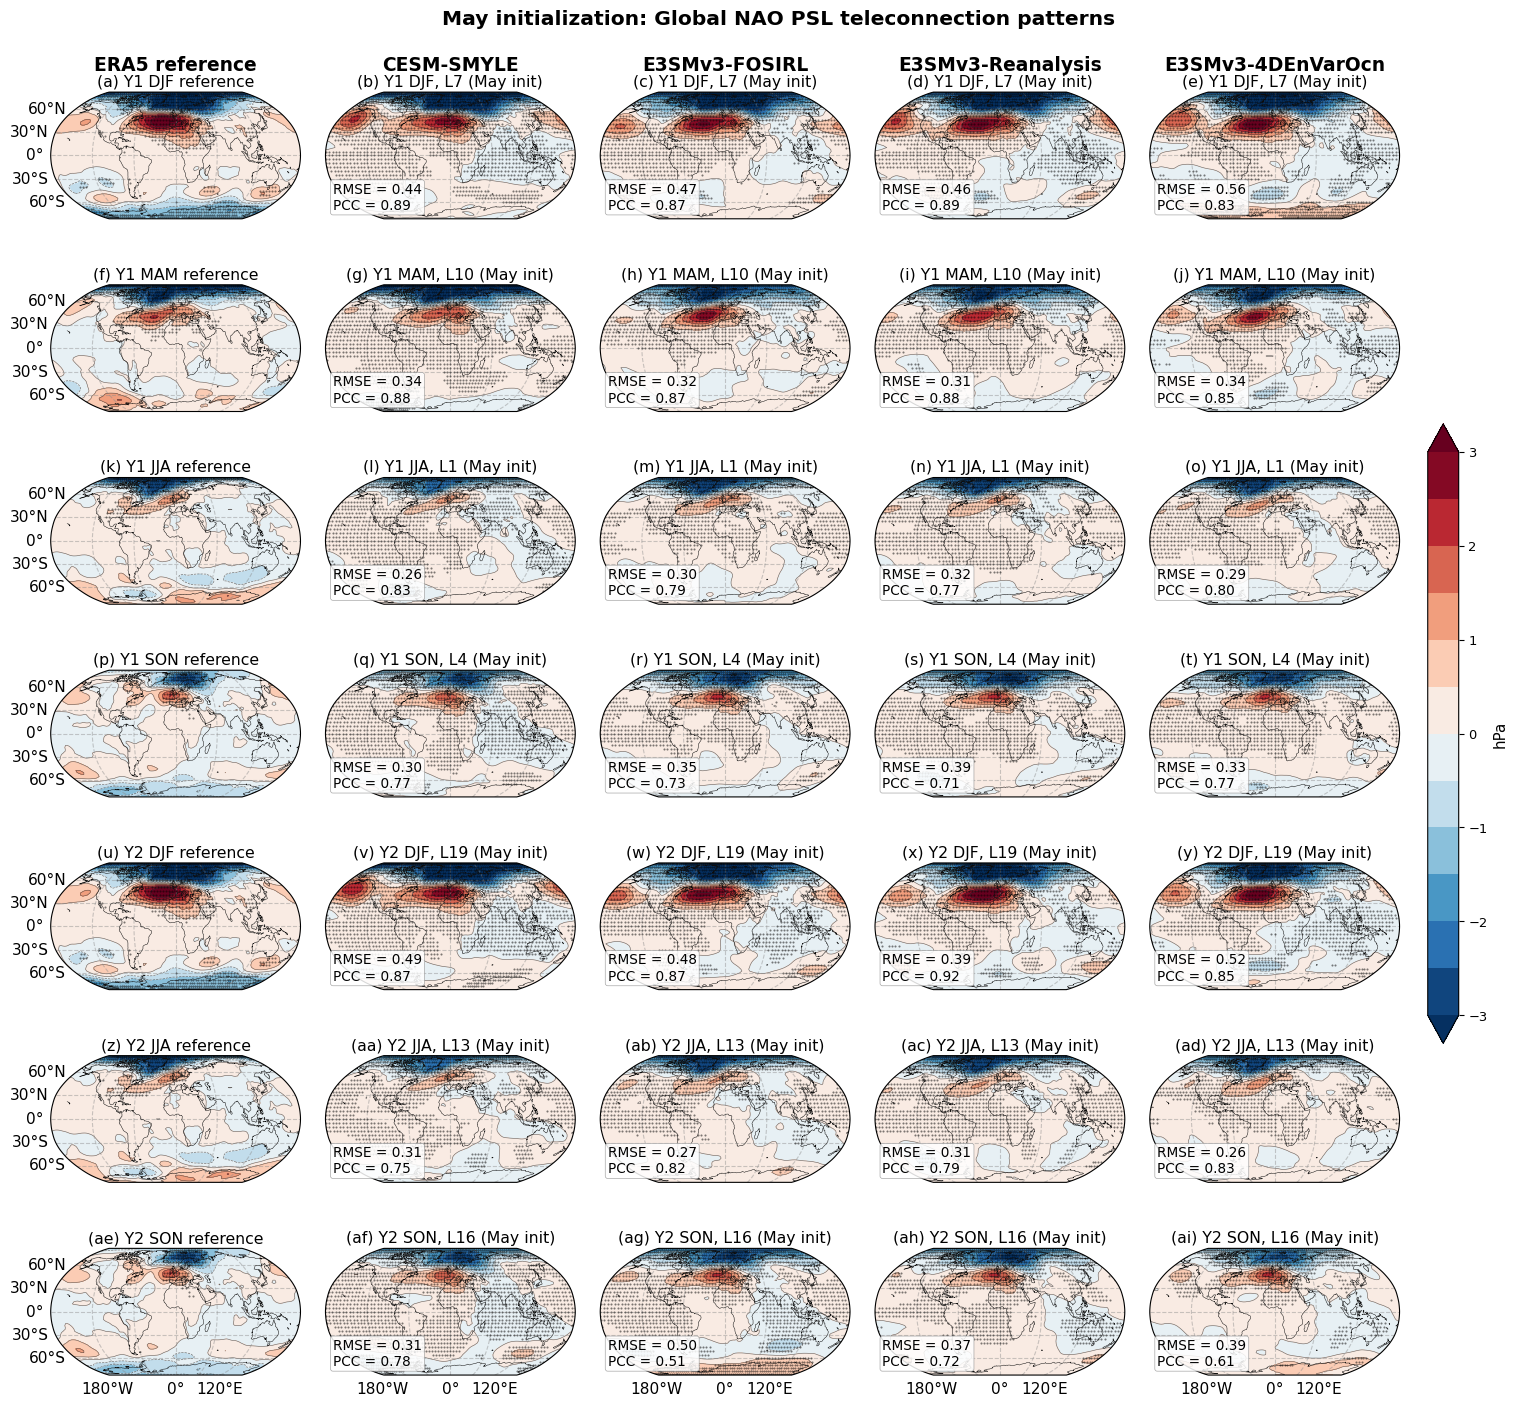

/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_nao_global_teleconnection_patterns_init11.png


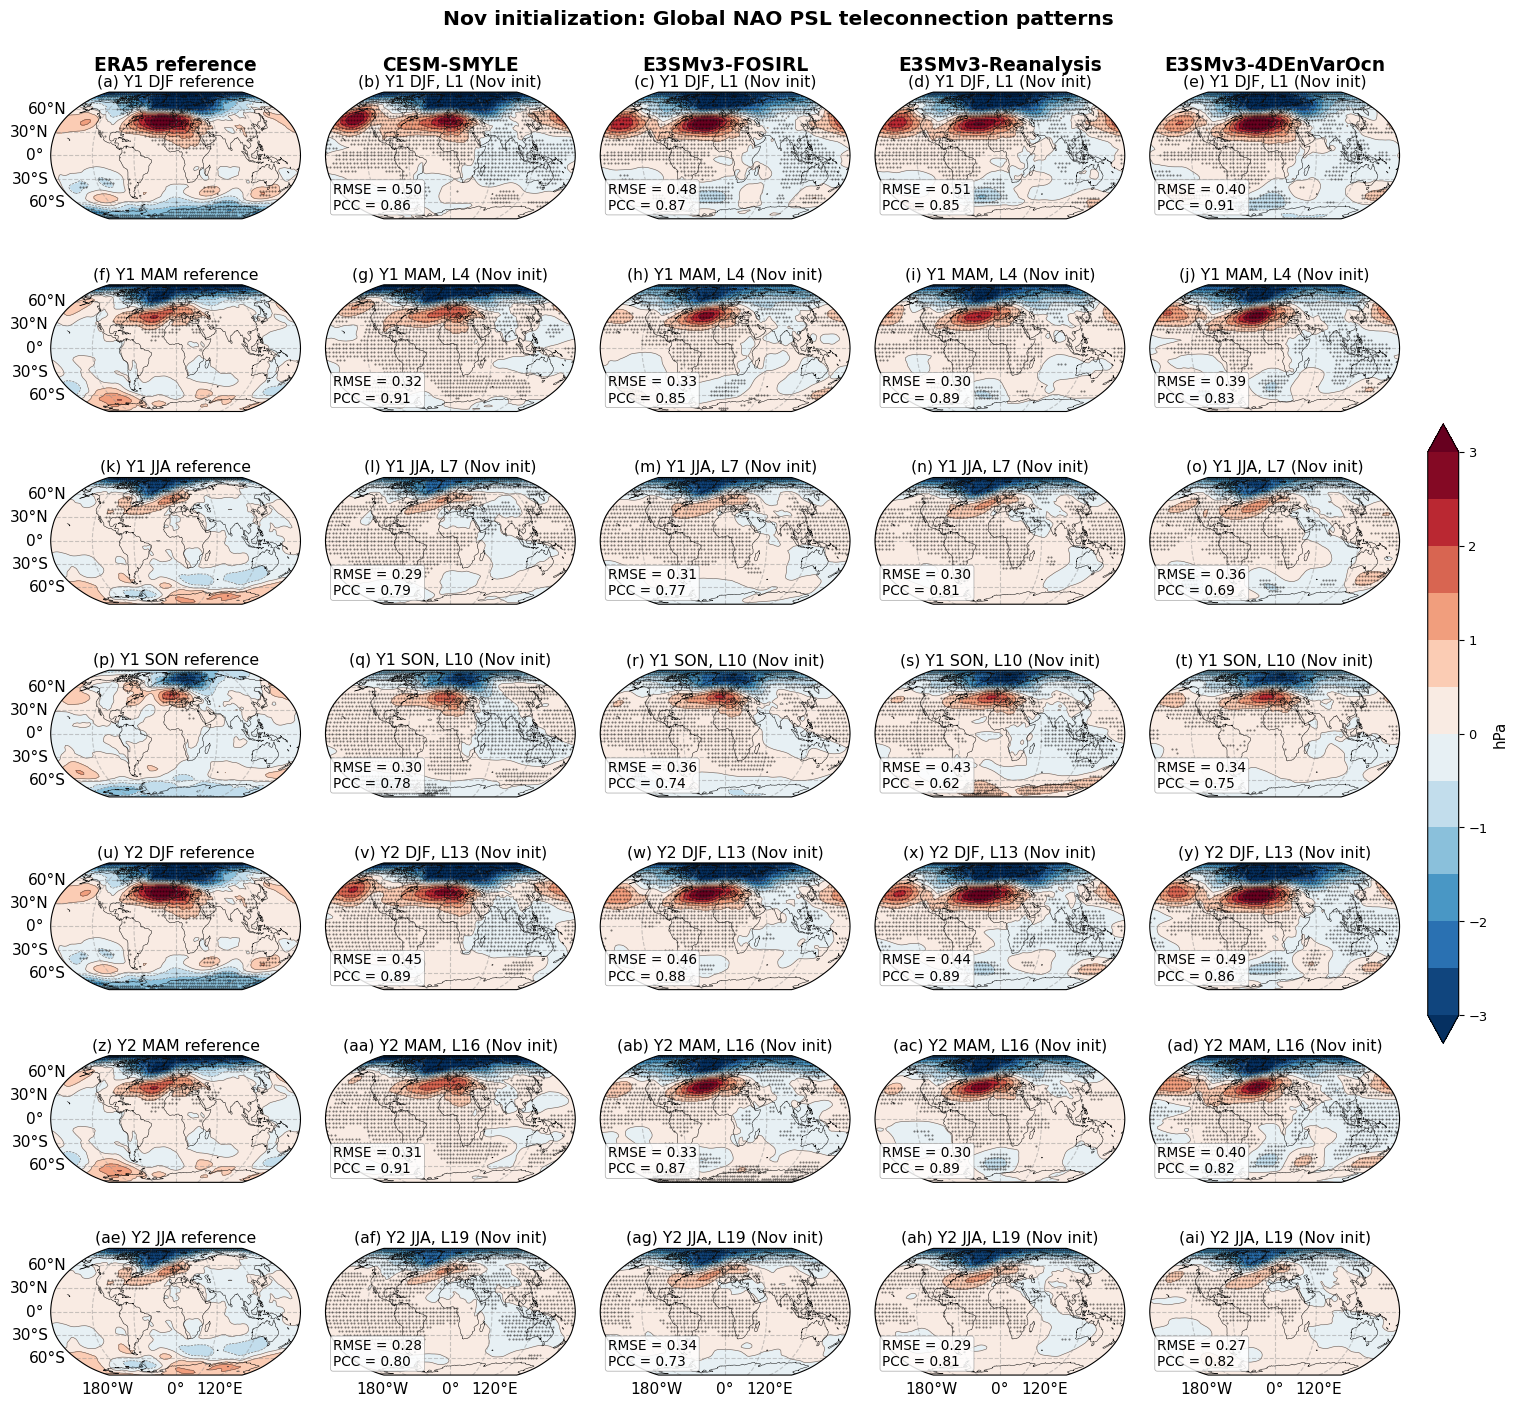

In [ ]:
# -----------------------------
# Plot global teleconnection regression patterns
# -----------------------------
teleconnection_variable = "mode_global_regression_pattern"
teleconnection_significance_variable = "mode_global_regression_significant"

reference_teleconnection_path = global_teleconnection_path(
    f"{selected_mode}:reference", obs_index_file
)
all_model_teleconnection_paths = {
    model: {
        init_month: global_teleconnection_path(
            f"{selected_mode}:{model_product_tags[model]}_init{init_month:02d}",
            model_index_files[model][init_month],
        )
        for init_month in init_months
    }
    for model in pattern_model_order
}
teleconnection_model_order = tuple(
    model
    for model in pattern_model_order
    if all(global_teleconnection_file_is_valid(path) for path in all_model_teleconnection_paths[model].values())
)
skipped_teleconnection_models = [
    model for model in pattern_model_order if model not in teleconnection_model_order
]
for model in skipped_teleconnection_models:
    print(f"Skipping {model} global teleconnections; products are missing or invalid:")
    for path in all_model_teleconnection_paths[model].values():
        if not global_teleconnection_file_is_valid(path):
            print(" ", path)

model_teleconnection_paths = {
    model: all_model_teleconnection_paths[model]
    for model in teleconnection_model_order
}
teleconnection_column_titles = [f"{reference_product} reference"] + [
    model_display_names[model] for model in teleconnection_model_order
]

if not global_teleconnection_file_is_valid(reference_teleconnection_path):
    print("Global reference teleconnection file is missing or invalid:", reference_teleconnection_path)
elif not teleconnection_model_order:
    print("No valid model teleconnection products are available. Rerun the input ensure cell with ensure_global_teleconnections=True.")
else:
    reference_teleconnection_ds = xr.open_dataset(reference_teleconnection_path).load()
    model_teleconnection_datasets = {
        model: {
            init_month: xr.open_dataset(path).load()
            for init_month, path in by_init.items()
        }
        for model, by_init in model_teleconnection_paths.items()
    }

    teleconnection_units = str(
        reference_teleconnection_ds[teleconnection_variable].attrs.get(
            "units", field_units
        )
    ).strip() or field_units
    lat_min = float(reference_teleconnection_ds.lat.min())
    lat_max = float(reference_teleconnection_ds.lat.max())
    if lat_min > -80 or lat_max < 80:
        raise ValueError(
            f"{reference_teleconnection_path.name} is not global: latitude "
            f"coverage is {lat_min:g} to {lat_max:g}."
        )

    teleconnection_plot = FIGURE_SETUP["teleconnections"]

    pacific_modes = {"PDO", "NPO", "NPGO", "PNA", "PSA1", "PSA2"}
    global_projection_name = (
        "pacific_global" if selected_mode in pacific_modes else "atlantic_global"
    )
    map_projection, map_projection_name = mov.make_projection(
        selected_mode,
        projection_by_mode={selected_mode: global_projection_name},
        use_cartopy=teleconnection_plot.get("use_cartopy", True),
    )
    data_crs = mov.data_crs() if map_projection is not None else None
    map_extent = [-180, 180, -90, 90]
    subplot_kw = {"projection": map_projection} if map_projection is not None else {}

    teleconnection_year_title_fontsize = (
        0.90 * fontz * teleconnection_plot.get("year_section_title_scale", 0.90)
    )
    teleconnection_column_header_fontsize = (
        0.88 * fontz * teleconnection_plot.get("column_header_scale", 0.85)
    )
    teleconnection_panel_title_fontsize = (
        0.90 * fontz * teleconnection_plot.get("panel_title_scale", 0.60)
    )
    teleconnection_map_label_fontsize = (
        0.82 * fontz * teleconnection_plot.get("map_label_scale", 0.55)
    )
    teleconnection_metric_box_fontsize = (
        0.88 * fontz * teleconnection_plot.get("metric_box_font_scale", 0.62)
    )

    pattern_cases_global = build_pattern_cases(include_all_initializations=True)
    cases_by_initialization = {
        init_month: [
            case for case in pattern_cases_global
            if case["init_month"] == init_month
        ]
        for init_month in init_months
    }
    cases_by_initialization = {
        init_month: cases for init_month, cases in cases_by_initialization.items()
        if cases
    }

    if not cases_by_initialization:
        raise ValueError("No global teleconnection pattern panels were selected.")

    def format_panel_label(idx):
        if idx < 26:
            return chr(ord("a") + idx)
        first = chr(ord("a") + (idx // 26) - 1)
        second = chr(ord("a") + (idx % 26))
        return f"{first}{second}"

    ncols = len(teleconnection_column_titles)
    fig_width = max(
        teleconnection_plot["figsize_width"],
        teleconnection_plot.get("figsize_column_width", 3.25) * ncols
        + teleconnection_plot.get("figsize_colorbar_width", 1.6),
    )

    for init_month, section_cases in cases_by_initialization.items():
        nrows = len(section_cases)
        fig_height = max(
            12.0,
            teleconnection_plot["figsize_row_height"] * nrows + 1.2
        )

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(fig_width, fig_height),
            subplot_kw=subplot_kw,
        )
        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1:
            axes = np.expand_dims(axes, axis=0)
        elif ncols == 1:
            axes = np.expand_dims(axes, axis=1)

        fig.subplots_adjust(
            left=teleconnection_plot.get("subplot_left", 0.045),
            right=teleconnection_plot.get("subplot_right", 0.925),
            bottom=teleconnection_plot.get("subplot_bottom", 0.035),
            top=teleconnection_plot.get("subplot_top", 0.92),
            wspace=teleconnection_plot.get("subplot_wspace", 0.10),
            hspace=teleconnection_plot.get("subplot_hspace", 0.22),
        )

        fig.suptitle(
            f"{month_names[init_month]} initialization: Global {selected_mode} "
            f"{source_field} teleconnection patterns",
            fontsize=teleconnection_year_title_fontsize,
            fontweight="bold",
            y=teleconnection_plot.get("year_title_y", 0.965),
            linespacing=teleconnection_plot.get("year_title_linespacing", 1.05),
        )

        for col, title in enumerate(teleconnection_column_titles):
            axes[0, col].text(
                0.5,
                1.0 + teleconnection_plot.get("column_header_y_shift", 0.14),
                title,
                transform=axes[0, col].transAxes,
                ha="center",
                va="bottom",
                fontsize=teleconnection_column_header_fontsize,
                fontweight="bold",
            )

        section_last_rows = {nrows - 1}
        images = []

        for row, case in enumerate(section_cases):
            lead = case["lead"]
            display_lead = case["display_lead"]
            target_month = case["target_month"]
            target_season = case["target_season"]
            target_year = case["target_year"]

            reference_pattern = normalize_global_longitude(
                reference_teleconnection_ds[teleconnection_variable].sel(
                    target_month=target_month
                )
            )
            reference_significant = None
            if teleconnection_significance_variable in reference_teleconnection_ds:
                reference_significant = normalize_global_longitude(
                    reference_teleconnection_ds[
                        teleconnection_significance_variable
                    ]
                    .sel(target_month=target_month)
                    .astype(bool)
                )

            panels = [
                (
                    reference_pattern,
                    (
                        f"Y{target_year} {target_season} reference"
                    ),
                    None,
                    reference_significant,
                )
            ]

            for model in teleconnection_model_order:
                dataset = model_teleconnection_datasets[model][init_month]
                model_leads = set(
                    map(int, dataset[teleconnection_variable].L.values)
                )
                if lead not in model_leads:
                    panels.append((None, f"{model} lead not available", None, None))
                    continue

                model_pattern = normalize_global_longitude(
                    dataset[teleconnection_variable].sel(L=lead)
                )
                model_significant = None
                if teleconnection_significance_variable in dataset:
                    model_significant = normalize_global_longitude(
                        dataset[teleconnection_significance_variable]
                        .sel(L=lead)
                        .astype(bool)
                    )

                rmse, pcc = mov.spatial_pattern_metrics(
                    model_pattern, reference_pattern
                )
                panels.append(
                    (
                        model_pattern,
                        (
                            f"Y{target_year} {target_season}, L{display_lead} "
                            f"({month_names[init_month]} init)"
                        ),
                        (
                            f"RMSE = {rmse:.{teleconnection_plot['rmse_decimals']}f}\n"
                            f"PCC = {pcc:.{teleconnection_plot['pcc_decimals']}f}"
                        ),
                        model_significant,
                    )
                )

            for col, (pattern, title, metrics_text, significant) in enumerate(panels):
                ax = axes[row, col]
                panel_label = format_panel_label(row * ncols + col)

                panel_title_x_by_col = teleconnection_plot.get("panel_title_x_by_col", {})
                title_kwargs = {
                    "loc": teleconnection_plot.get("panel_title_loc", "left"),
                    "fontsize": teleconnection_panel_title_fontsize,
                }
                if "panel_title_x" in teleconnection_plot or col in panel_title_x_by_col:
                    title_kwargs["x"] = panel_title_x_by_col.get(col, teleconnection_plot.get("panel_title_x"))
                if "panel_title_y" in teleconnection_plot:
                    title_kwargs["y"] = teleconnection_plot["panel_title_y"]
                if "panel_title_ha" in teleconnection_plot:
                    title_kwargs["ha"] = teleconnection_plot["panel_title_ha"]
                if "panel_title_pad" in teleconnection_plot:
                    title_kwargs["pad"] = teleconnection_plot["panel_title_pad"]
                if "panel_title_linespacing" in teleconnection_plot:
                    title_kwargs["linespacing"] = teleconnection_plot["panel_title_linespacing"]

                if pattern is None:
                    ax.set_axis_off()
                    ax.set_title(
                        f"({panel_label}) {title}",
                        **title_kwargs
                    )
                    continue

                plot_pattern = mov.add_cyclic_longitude_for_plot(pattern)
                image = ax.contourf(
                    plot_pattern.lon,
                    plot_pattern.lat,
                    plot_pattern,
                    levels=levels,
                    cmap="RdBu_r",
                    extend="both",
                    transform=data_crs,
                )
                images.append(image)

                if teleconnection_plot["draw_contour_lines"]:
                    ax.contour(
                        plot_pattern.lon,
                        plot_pattern.lat,
                        plot_pattern,
                        levels=teleconnection_plot["contour_line_levels"],
                        colors=teleconnection_plot["contour_line_color"],
                        linewidths=teleconnection_plot["contour_linewidth"],
                        alpha=teleconnection_plot["contour_line_alpha"],
                        transform=data_crs,
                    )

                if significant is not None:
                    plot_significant = mov.add_cyclic_longitude_for_plot(significant)
                    stipple = plot_significant.isel(
                        lat=slice(None, None, teleconnection_plot["stipple_stride"]),
                        lon=slice(None, None, teleconnection_plot["stipple_stride"]),
                    )
                    stipple_lon, stipple_lat = np.meshgrid(stipple.lon, stipple.lat)
                    ax.scatter(
                        stipple_lon[stipple.values],
                        stipple_lat[stipple.values],
                        s=teleconnection_plot["stipple_size"],
                        color=teleconnection_plot["stipple_color"],
                        alpha=teleconnection_plot["stipple_alpha"],
                        marker=".",
                        linewidths=0,
                        zorder=teleconnection_plot["stipple_zorder"],
                        transform=data_crs,
                    )

                if map_projection is not None:
                    mov.set_extent(ax, map_projection_name, map_extent, data_crs)
                    mov.add_map_features(ax, map_projection_name, teleconnection_plot)
                    mov.configure_gridlines(
                        ax,
                        mode=selected_mode,
                        projection_name=map_projection_name,
                        row=row,
                        col=col,
                        section_last_rows=section_last_rows,
                        extent=map_extent,
                        data_projection=data_crs,
                        settings=teleconnection_plot,
                        fontsize=teleconnection_map_label_fontsize,
                    )
                else:
                    ax.set_xlim(float(plot_pattern.lon.min()), float(plot_pattern.lon.max()))
                    ax.set_ylim(float(plot_pattern.lat.min()), float(plot_pattern.lat.max()))
                    ax.grid(True, alpha=teleconnection_plot["grid_alpha"])

                ax.set_title(
                    f"({panel_label}) {title}",
                    **title_kwargs
                )
                if metrics_text:
                    metric_display = metrics_text
                    if teleconnection_plot.get("metric_box_two_lines", True):
                        metric_display = metric_display.replace(", ", "\n").replace("; ", "\n")
                    ax.text(
                        teleconnection_plot.get("metric_box_x", 0.03),
                        teleconnection_plot.get("metric_box_y", 0.05),
                        metric_display,
                        transform=ax.transAxes,
                        fontsize=teleconnection_metric_box_fontsize,
                        ha=teleconnection_plot.get("metric_box_ha", "left"),
                        va=teleconnection_plot.get("metric_box_va", "bottom"),
                        bbox=dict(
                            facecolor="white",
                            alpha=teleconnection_plot.get("metric_box_alpha", 0.85),
                            edgecolor="0.6",
                            linewidth=teleconnection_plot.get("metric_box_linewidth", 0.5),
                            boxstyle=f"round,pad={teleconnection_plot.get('metric_box_pad', 0.18)}",
                        ),
                        clip_on=False,
                        zorder=teleconnection_plot.get("metric_box_zorder", 4),
                    )

        if images:
            colorbar = fig.colorbar(
                images[-1],
                ax=axes.ravel().tolist(),
                orientation="vertical",
                shrink=teleconnection_plot.get("colorbar_shrink", 0.78),
                pad=teleconnection_plot.get("colorbar_pad", 0.02),
                fraction=teleconnection_plot.get("colorbar_fraction", 0.022),
            )
            colorbar.set_label(teleconnection_units, fontsize=colorbar_label_fontsize)
            colorbar.ax.tick_params(labelsize=colorbar_tick_fontsize)

        figpath = FIGURE_OUTDIR / mov.figure_filename(
            selected_mode, "global_teleconnection_patterns", f"init{init_month:02d}"
        )
        mov.save_figure(
            fig,
            figpath,
            mode=selected_mode,
            metric=f"global_teleconnection_patterns_init{init_month:02d}",
            title=f"Global {selected_mode} {source_field} Teleconnection Patterns ({month_names[init_month]} Init)",
            caption=(
                f"Full-map {source_field} regression patterns onto {selected_mode} PCs, "
                f"{month_names[init_month]} init, "
                f"hindcast initializations {hindcast_init_year0}-{hindcast_init_year1}, "
                f"EOF reference {eof_reference_year0}-{eof_reference_year1}, "
                f"{reference_product} reference"
            ),
            dpi=figure_dpi,
            reference=reference_product,
        )
        print(figpath)
        plt.show()
        plt.close(fig)

## Global Teleconnection Summary Metrics

This table summarizes the same global teleconnection regression patterns plotted above. It compares each model pattern against the reference pattern for every selected initialization month, target year, and target season.


In [ ]:
# -----------------------------
# Summarize global teleconnection pattern metrics
# -----------------------------
teleconnection_summary_rows = []

if "reference_teleconnection_ds" not in globals() or "model_teleconnection_datasets" not in globals():
    print("Global teleconnection datasets are not loaded; run the global teleconnection diagnostics cell first.")
elif "pattern_cases" not in globals() or not pattern_cases:
    print("No pattern cases are available for teleconnection summary metrics.")
else:
    def teleconnection_spatial_std_ratio(model_pattern, reference_pattern):
        model_pattern, reference_pattern = xr.align(
            model_pattern, reference_pattern, join="inner"
        )
        common_dims = [
            dim for dim in model_pattern.dims
            if dim in reference_pattern.dims and dim in {"lat", "latitude", "lon", "longitude"}
        ]
        if not common_dims:
            return np.nan
        valid = np.isfinite(model_pattern) & np.isfinite(reference_pattern)
        model_valid = model_pattern.where(valid)
        reference_valid = reference_pattern.where(valid)
        reference_std = float(reference_valid.std(dim=common_dims, skipna=True))
        if not np.isfinite(reference_std) or reference_std == 0:
            return np.nan
        return float(model_valid.std(dim=common_dims, skipna=True) / reference_std)

    for case in globals().get("pattern_cases_global", pattern_cases):
        init_month = case["init_month"]
        lead = case["lead"]
        target_month = case["target_month"]
        target_year = case["target_year"]
        target_season = case["target_season"]
        display_lead = case["display_lead"]

        reference_pattern = normalize_global_longitude(
            reference_teleconnection_ds[teleconnection_variable].sel(
                target_month=target_month
            )
        )

        for model in teleconnection_model_order:
            dataset = model_teleconnection_datasets.get(model, {}).get(init_month)
            available_leads = (
                set(map(int, dataset[teleconnection_variable].L.values))
                if dataset is not None and teleconnection_variable in dataset
                else set()
            )
            if lead not in available_leads:
                teleconnection_summary_rows.append(
                    {
                        "mode": selected_mode,
                        "model": model,
                        "init_month": init_month,
                        "lead": lead,
                        "display_lead": display_lead,
                        "target_year": target_year,
                        "target_month": target_month,
                        "target_season": target_season,
                        "status": "missing global teleconnection pattern",
                    }
                )
                continue

            model_pattern = normalize_global_longitude(
                dataset[teleconnection_variable].sel(L=lead)
            )
            rmse, pcc = mov.spatial_pattern_metrics(model_pattern, reference_pattern)
            amplitude_ratio = teleconnection_spatial_std_ratio(
                model_pattern, reference_pattern
            )

            significant_fraction = np.nan
            if teleconnection_significance_variable in dataset:
                significant_fraction = float(
                    dataset[teleconnection_significance_variable]
                    .sel(L=lead)
                    .astype(bool)
                    .mean(skipna=True)
                )

            teleconnection_summary_rows.append(
                {
                    "mode": selected_mode,
                    "model": model,
                    "model_label": model_display_names.get(model, model),
                    "init_month": init_month,
                    "lead": lead,
                    "display_lead": display_lead,
                    "target_year": target_year,
                    "target_month": target_month,
                    "target_season": target_season,
                    "rmse": rmse,
                    "pattern_correlation": pcc,
                    "amplitude_ratio": amplitude_ratio,
                    "significant_area_fraction": significant_fraction,
                    "reference_file": str(reference_teleconnection_path),
                    "model_file": str(model_teleconnection_paths[model][init_month]),
                    "status": "ok",
                }
            )

teleconnection_summary_df = pd.DataFrame(teleconnection_summary_rows)

if teleconnection_summary_df.empty:
    display(teleconnection_summary_df)
else:
    metric_columns = [
        "mode", "model", "init_month", "display_lead", "target_year",
        "target_season", "rmse", "pattern_correlation", "amplitude_ratio",
        "significant_area_fraction", "status",
    ]
    display(
        teleconnection_summary_df[metric_columns]
        .sort_values(["target_year", "target_season", "model", "init_month"])
        .reset_index(drop=True)
    )

    if write_summary_tables:
        table_outdir.mkdir(parents=True, exist_ok=True)
        metrics_stem = f"{selected_mode.lower()}_global_teleconnection_summary_metrics"
        metrics_csv = table_outdir / f"{metrics_stem}.csv"
        metrics_txt = table_outdir / f"{metrics_stem}.txt"
        teleconnection_summary_df.to_csv(metrics_csv, index=False, float_format="%.4f")
        metrics_txt.write_text(
            teleconnection_summary_df.to_string(
                index=False, float_format=lambda value: f"{value:.4f}"
            )
        )
        print(metrics_csv)
        print(metrics_txt)


,mode,model,init_month,display_lead,target_year,target_season,rmse,pattern_correlation,amplitude_ratio,significant_area_fraction,status
0,NAO,E3SM-4DEnVarOcn,5,7,1,DJF,0.562193,0.826601,0.959794,0.644882,ok
1,NAO,E3SM-4DEnVarOcn,11,1,1,DJF,0.395240,0.913264,0.852921,0.537291,ok
2,NAO,E3SM-FOSIRL,5,7,1,DJF,0.474371,0.874596,0.955341,0.534151,ok
3,NAO,E3SM-FOSIRL,11,1,1,DJF,0.482399,0.869787,0.900139,0.550989,ok
4,NAO,E3SM-Reanalysis,5,7,1,DJF,0.455662,0.885697,0.949862,0.565259,ok
5,NAO,E3SM-Reanalysis,11,1,1,DJF,0.513890,0.850073,0.913632,0.522165,ok
6,NAO,SMYLE,5,7,1,DJF,0.438817,0.894268,1.005579,0.619387,ok
7,NAO,SMYLE,11,1,1,DJF,0.504722,0.859134,0.979452,0.579243,ok
8,NAO,E3SM-4DEnVarOcn,5,1,1,JJA,0.285579,0.804219,0.933933,0.440449,ok
9,NAO,E3SM-4DEnVarOcn,11,7,1,JJA,0.358496,0.688433,0.811963,0.458904,ok


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/nao_global_teleconnection_summary_metrics.csv
/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/modes_variability/tables/nao_global_teleconnection_summary_metrics.txt


In [ ]:
print(
    f"{selected_mode} analysis complete. Processed-data directory:",
    index_cache_dir,
)

NAO analysis complete. Processed-data directory: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/modes/nao/indices
